# Exercise 6 Digitization and Data Analytics 

In [97]:
!pip install torch torchvision torchaudio "torch"

zsh:1: command not found: pip


## Deep Learning

Content

- Introduction
- Fundamental concepts in interaction with Torch
- Design, training, and learning of a simple neural network

### Introduction
Basic explanation of a neural network model in Keras: https://towardsdatascience.com/building-a-deep-learning-model-using-keras-1548ca149d37.

The operations during training and usage of neural networks are done on matrices. Thus, you should be familiar with the necessary concepts of Linear Algebra.

If you need a brush up:
- https://www.youtube.com/watch?v=fNk_zzaMoSs&list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab
- https://www.youtube.com/watch?v=7UJ4CFRGd-U&list=PLE7DDD91010BC51F8

### Preparation
We will use Torch within this notebook, but also introduce you to underlying concepts which should be helpful to switch frameworks if needed.

Make sure, that plot_lib.py is in the same directory as your notebook.

In [98]:
import torch
import torch.nn as nn
import numpy as np
import random
import math
from plot_lib import set_default, show_scatterplot, plot_bases, plot_data
from IPython import display

#### Matrix operations

Note : Python 3 also supports matrix multiplication using a special operater "@"

In [99]:
x = np.array([1, 1, 1])
y = np.array([1, 1, 1])

In [100]:
x@y

np.int64(3)

**Exercise**: If you are not familiar with matrice operations, do the following:
- Run a simple vector x vector multiplication.
- Run a simple vector x matrix multiplication. 
- Run a Matrix x Matrix multiplication.

In [101]:
# --- Exercise: Matrix Operations ---

# Vector x Vector multiplication (dot product)
v1 = torch.tensor([1.0, 2.0, 3.0])
v2 = torch.tensor([4.0, 5.0, 6.0])
dot_product = torch.dot(v1, v2)
print("Vector x Vector:")
print(f"{v1} . {v2} = {dot_product}\n")

# Vector x Matrix multiplication
v = torch.tensor([1.0, 2.0])
M = torch.tensor([[3.0, 4.0], 
                  [5.0, 6.0]])
vec_mat_mult = torch.matmul(v, M) # or v @ M
print("Vector x Matrix:")
print(f"{v} @ \n{M}\n= {vec_mat_mult}\n")

# Matrix x Matrix multiplication
M1 = torch.tensor([[1.0, 2.0], 
                   [3.0, 4.0]])
M2 = torch.tensor([[5.0, 6.0], 
                   [7.0, 8.0]])
mat_mat_mult = torch.matmul(M1, M2) # or M1 @ M2
print("Matrix x Matrix:")
print(f"{M1} @ \n{M2}\n= \n{mat_mat_mult}")

Vector x Vector:
tensor([1., 2., 3.]) . tensor([4., 5., 6.]) = 32.0

Vector x Matrix:
tensor([1., 2.]) @ 
tensor([[3., 4.],
        [5., 6.]])
= tensor([13., 16.])

Matrix x Matrix:
tensor([[1., 2.],
        [3., 4.]]) @ 
tensor([[5., 6.],
        [7., 8.]])
= 
tensor([[19., 22.],
        [43., 50.]])


### Neural Networks
You find a basic explanation of Neural Network models in Keras here:
- https://towardsdatascience.com/building-a-deep-learning-model-using-keras-1548ca149d37

How to interpret the deep learning operations? It is basically a rotation of n-dimensional vectors followed by a non-linearity (which allows the vector to "bend"). 

Please use the links above if the intuition of the above statement is lacking.

In [102]:
set_default()

In [103]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In order to visualize the operations within a neural network, we randomly generate a 
set of 2-D data and present the in a plot.

In [104]:
# generate some points in 2-D space
n_points = 1000
X = torch.randn(n_points, 2).to(device)
colors = X[:, 0]

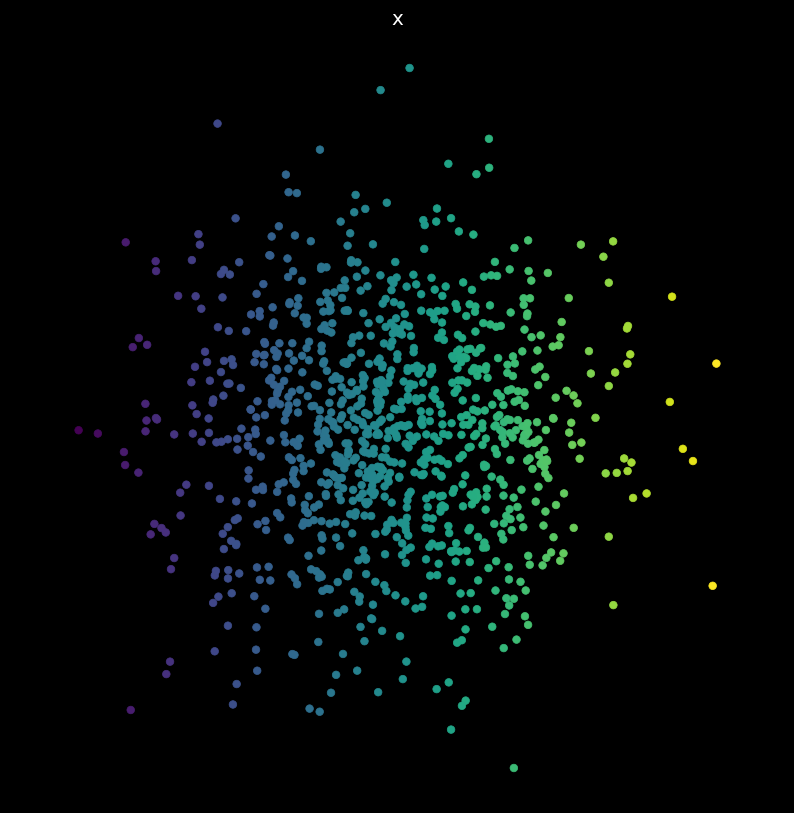

In [105]:
show_scatterplot(X, colors, title='x')

**Exercise**: In the following, a simple neural network is defined, and the resulting data 
    points are plotted.
- Change the activation function in order to see its impact on the data. 

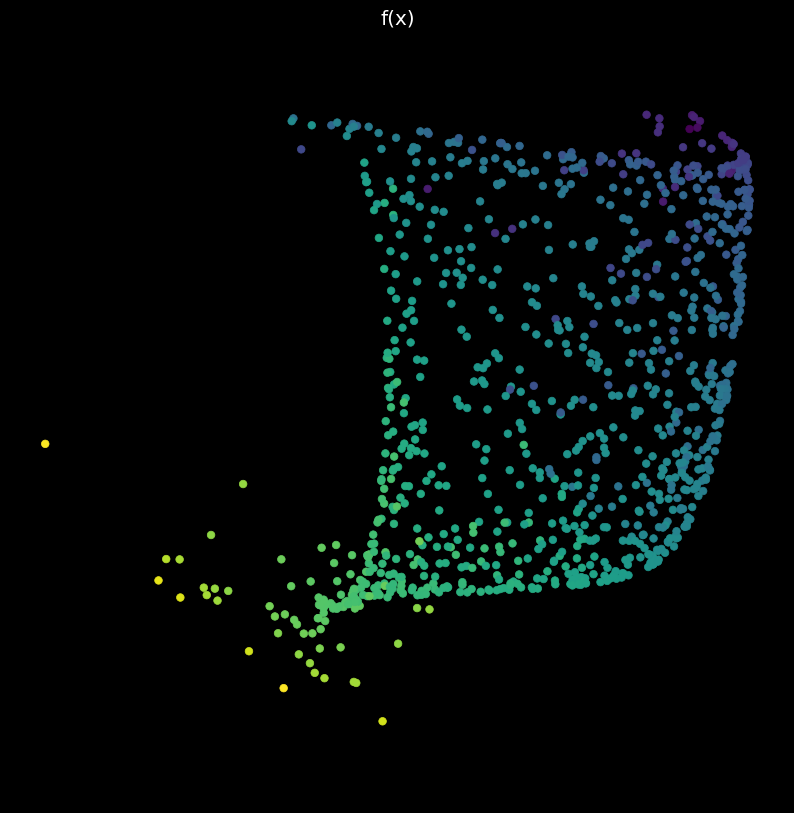

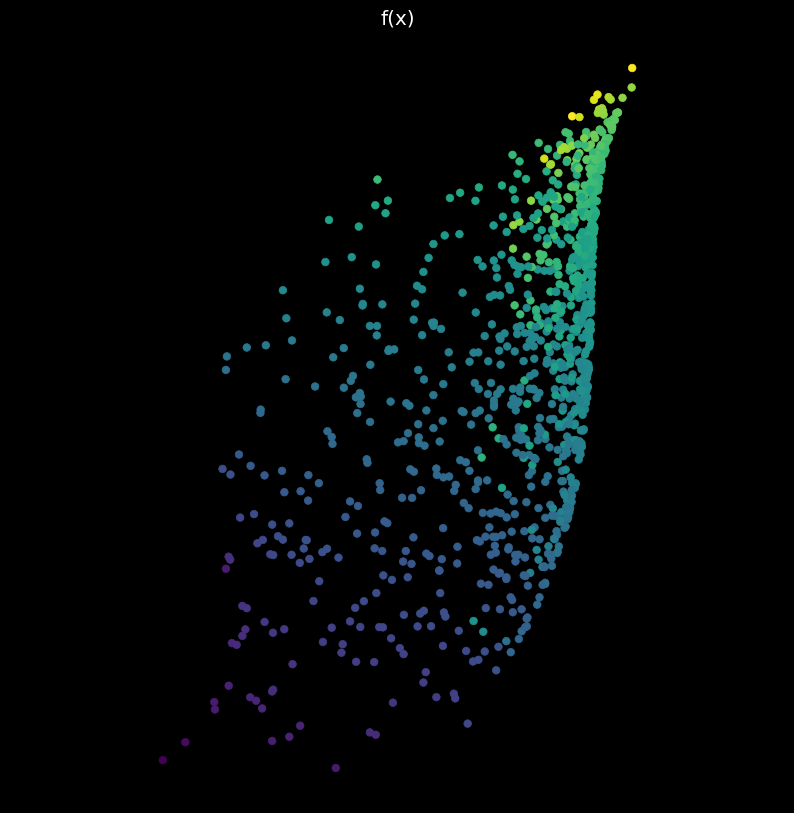

In [106]:
n_hidden = 5

# NL = nn.ReLU()
NL = nn.Tanh()

for i in range(2):
    # create 1-layer neural networks with random weights
    model = nn.Sequential(
            nn.Linear(2, n_hidden), 
            NL, 
            nn.Linear(n_hidden, 2)
        )
    model.to(device)
    with torch.no_grad():
        Y = model(X)
    show_scatterplot(Y, colors, title='f(x)')

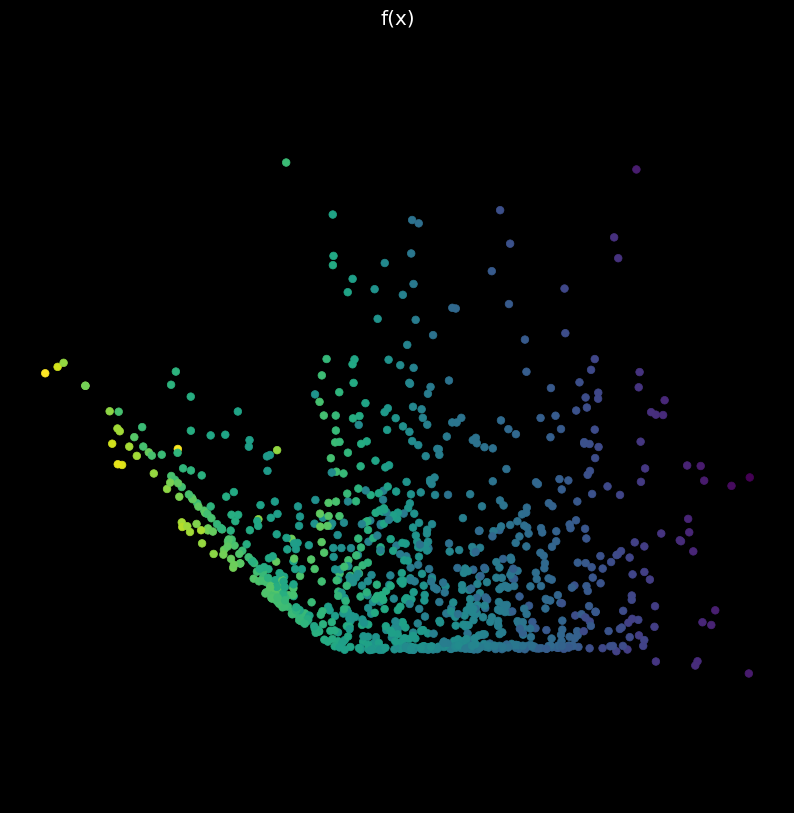

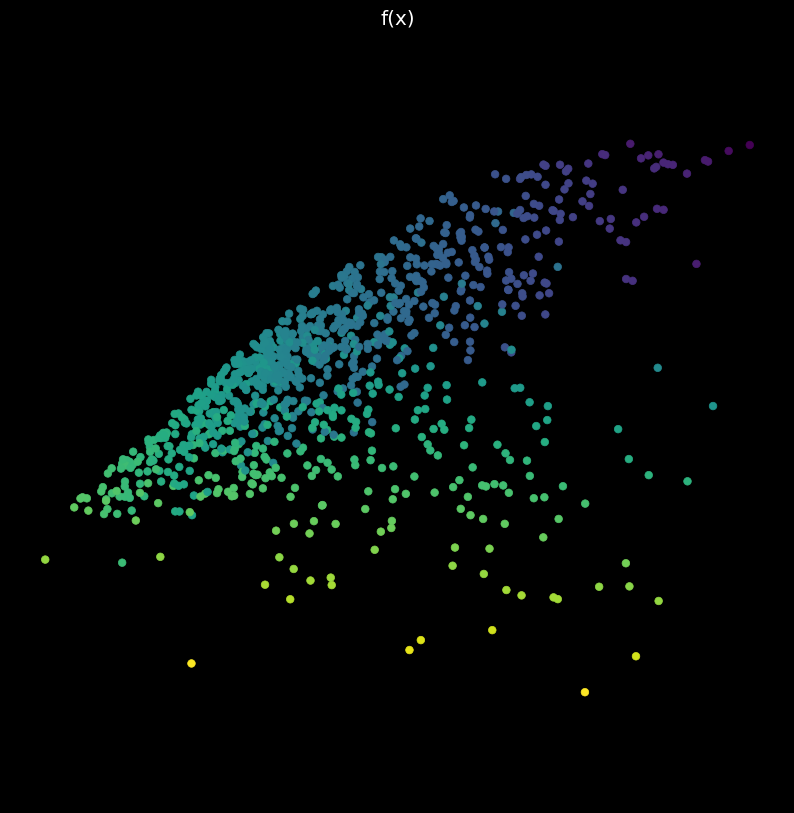

In [107]:
n_hidden = 5

NL = nn.ReLU()
# NL = nn.Tanh()

for i in range(2):
    # create 1-layer neural networks with random weights
    model = nn.Sequential(
            nn.Linear(2, n_hidden), 
            NL, 
            nn.Linear(n_hidden, 2)
        )
    model.to(device)
    with torch.no_grad():
        Y = model(X)
    show_scatterplot(Y, colors, title='f(x)')

--- Activation Function: ReLU ---


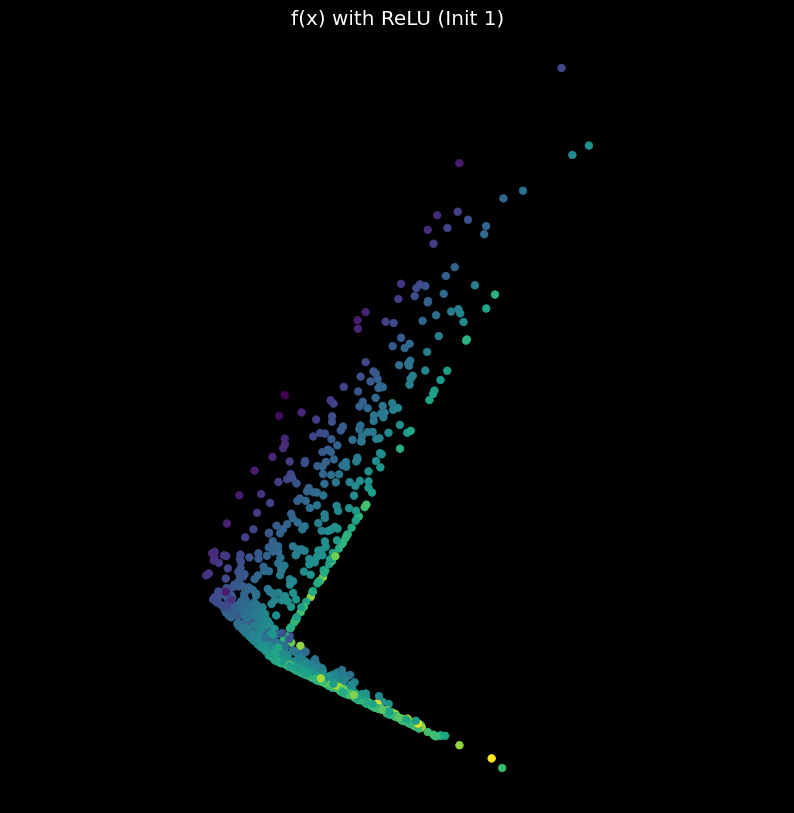

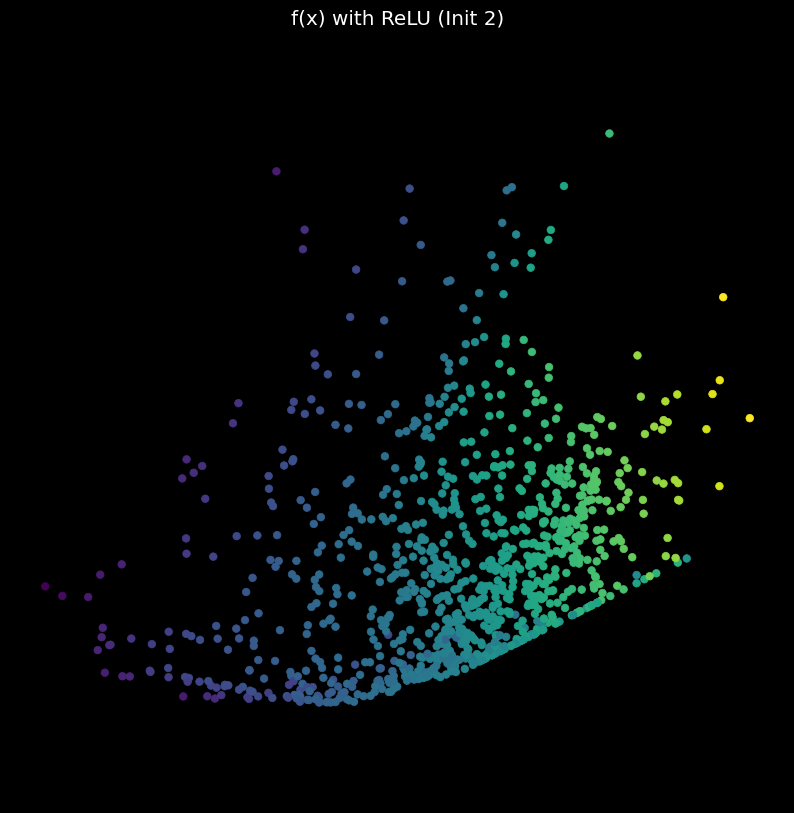

--- Activation Function: Tanh ---


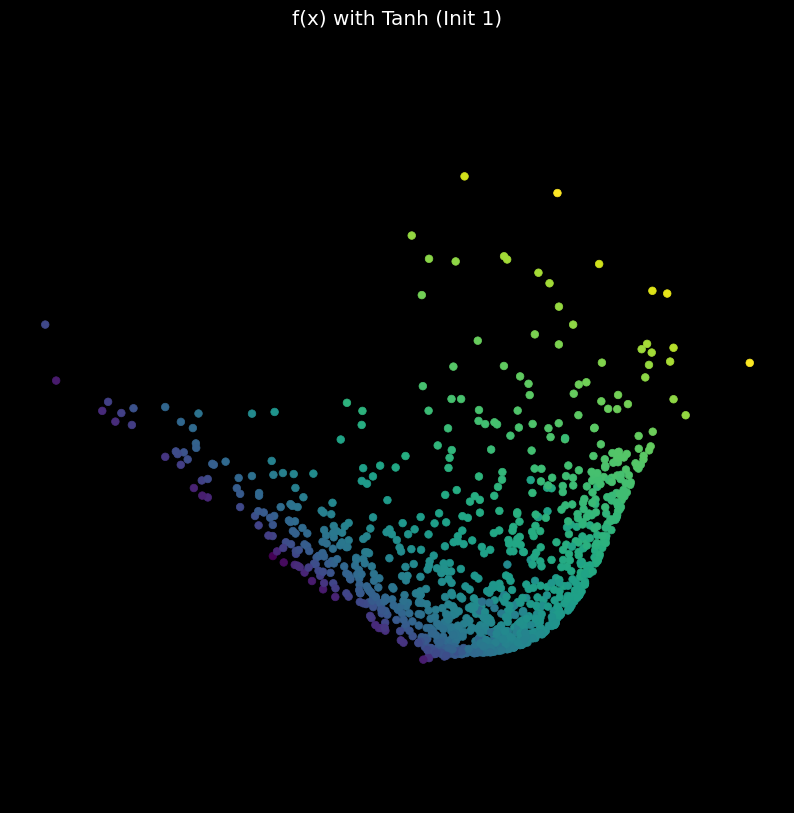

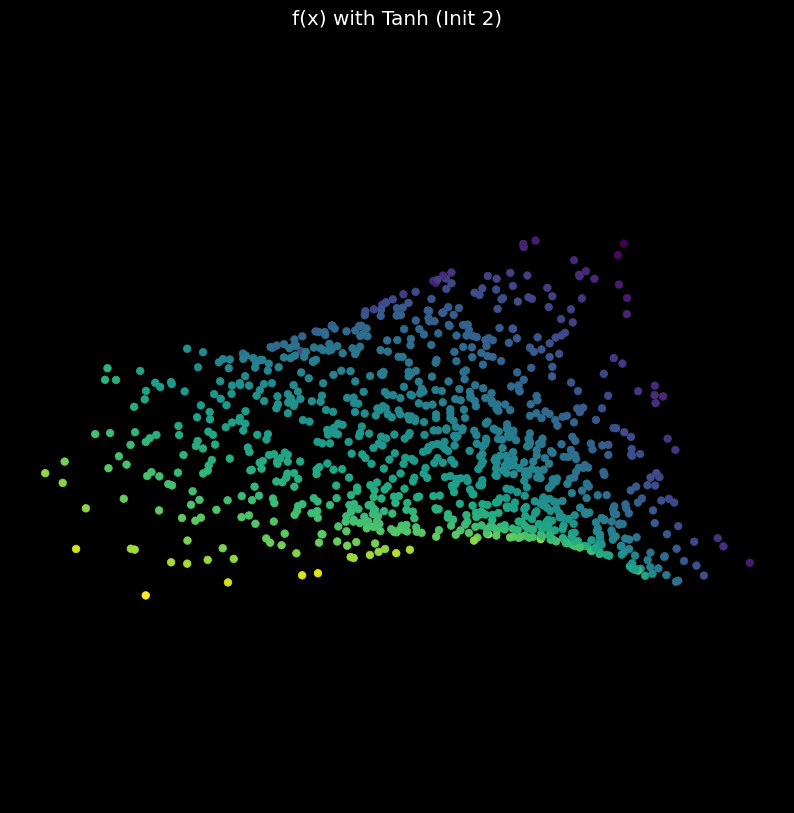

--- Activation Function: Sigmoid ---


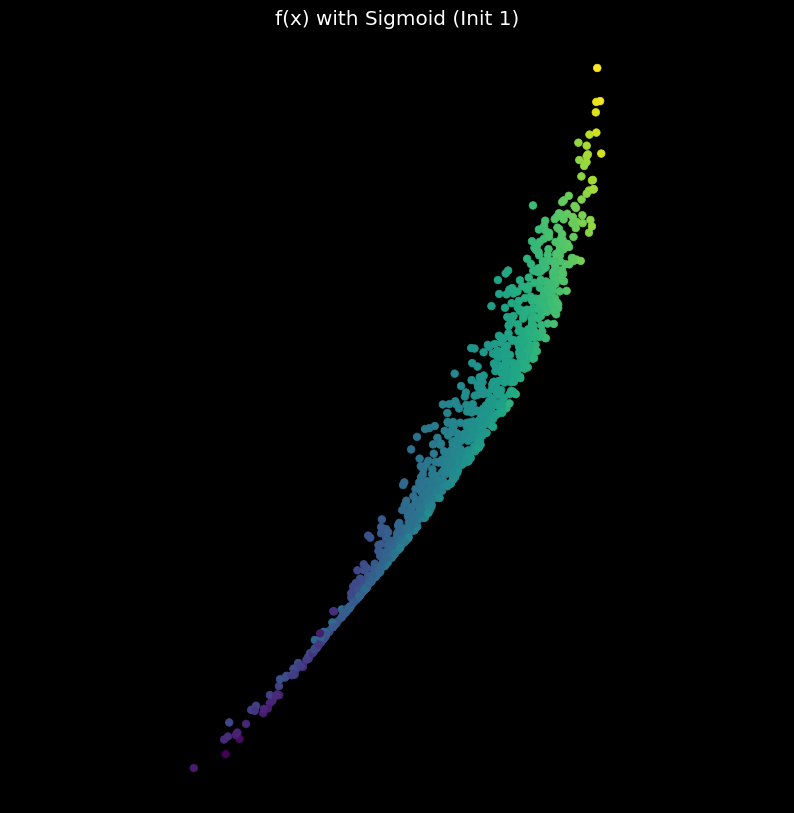

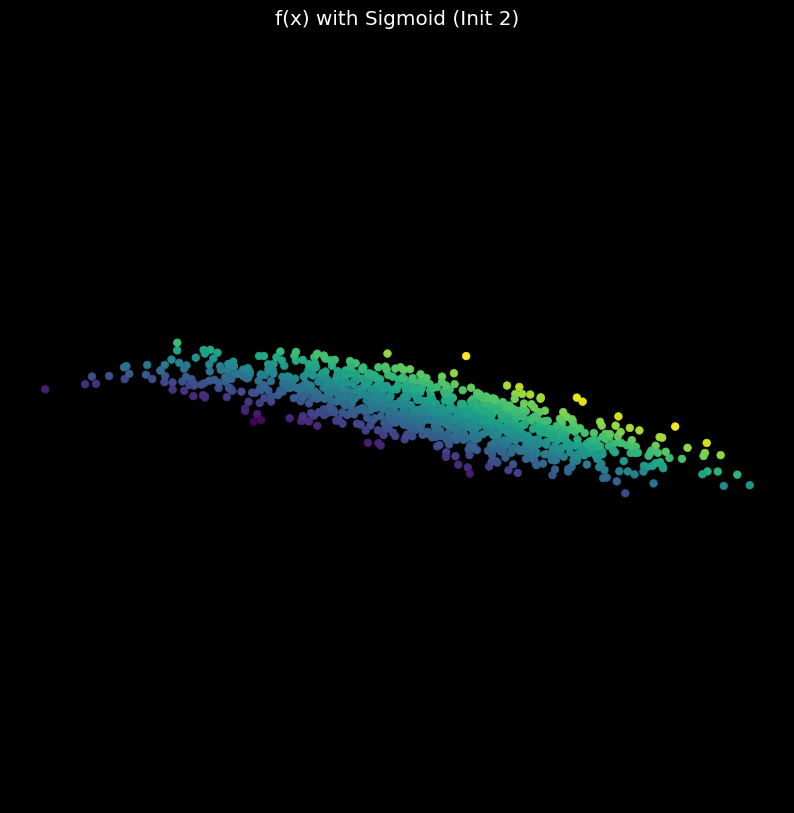

--- Activation Function: LeakyReLU ---


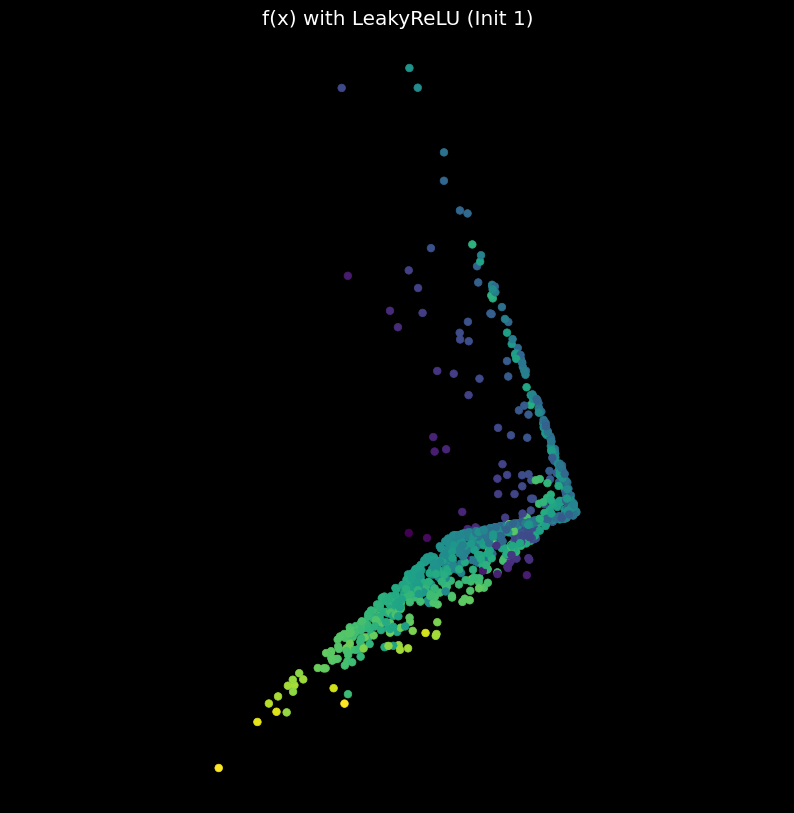

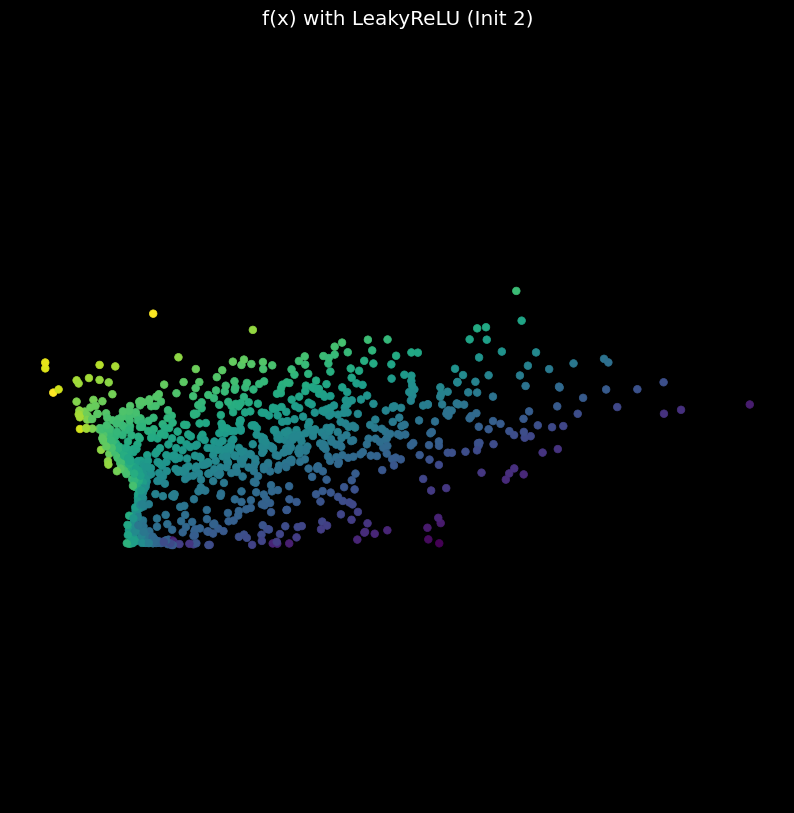

In [108]:
# --- Exercise: Change the activation function ---

import torch.nn as nn

n_hidden = 5
activations = {
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "Sigmoid": nn.Sigmoid(),
    "LeakyReLU": nn.LeakyReLU(0.1)
}

for name, NL in activations.items():
    print(f"--- Activation Function: {name} ---")
    for i in range(2): # Show 2 random initializations per activation
        model = nn.Sequential(
            nn.Linear(2, n_hidden), 
            NL, 
            nn.Linear(n_hidden, 2)
        )
        model.to(device)
        with torch.no_grad():
            Y = model(X)
        show_scatterplot(Y, colors, title=f'f(x) with {name} (Init {i+1})')
    # Use plt.show() to ensure figures are flushed before the next activation text
    import matplotlib.pyplot as plt
    plt.show()

### Train a simple Neural Network on sample data

In the following, we train a model and see how the data is modified.

The different steps are:
1. Build your model.
2. Build a DataLoader. This tells the computer how to read data (can be text, images, videos etc, ).
3. Build a training loop. Need to specify the how to update the model params each pass of the data. Loss, Regularisation, etc happens here.

In [109]:
seed = 12345
random.seed(seed)
torch.manual_seed(seed)
N = 1000  # num_samples_per_class
D = 2  # dimensions
C = 2  # num_classes
H = 100  # num_hidden_units

In [110]:
X = torch.zeros(N * C, D).to(device)
y = torch.zeros(N * C, dtype=torch.long).to(device)
for c in range(C):
    index = 0
    t = torch.linspace(0, 1, N)
    # When c = 0 and t = 0: start of linspace
    # When c = 0 and t = 1: end of linpace
    # This inner_var is for the formula inside sin() and cos() like sin(inner_var) and cos(inner_Var)
    inner_var = torch.linspace(
        # When t = 0
        (2 * math.pi / C) * (c),
        # When t = 1
        (2 * math.pi / C) * (2 + c),
        N
    ) + torch.randn(N) * 0.2
    
    for ix in range(N * c, N * (c + 1)):
        X[ix] = t[index] * torch.FloatTensor((
            math.sin(inner_var[index]), math.cos(inner_var[index])
        ))
        y[ix] = c
        index += 1

print("Shapes:")
print("X:", tuple(X.size()))
print("y:", tuple(y.size()))

Shapes:
X: (2000, 2)
y: (2000,)


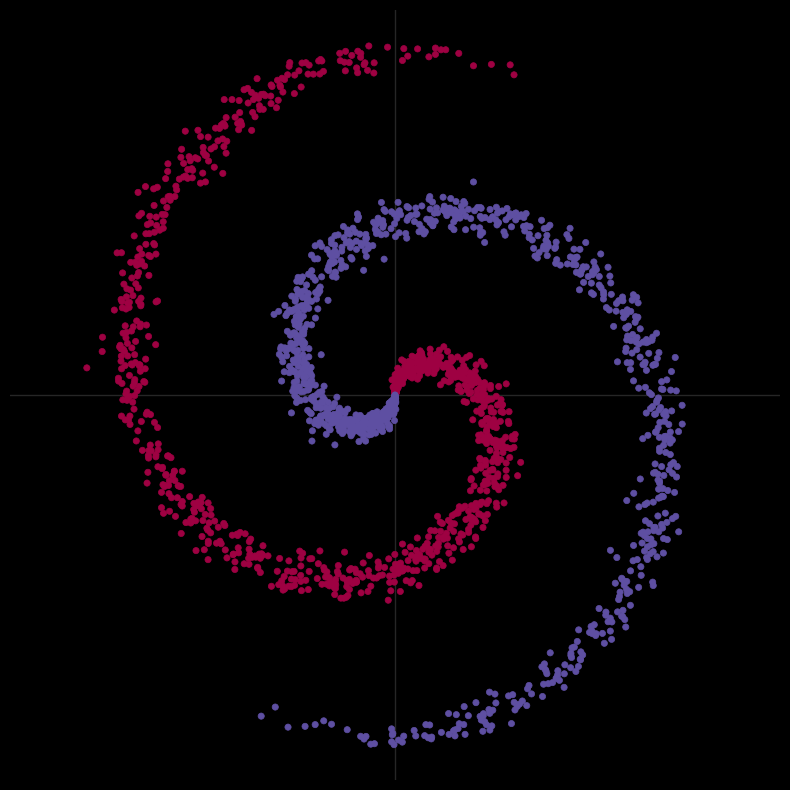

In [111]:
plot_data(X, y)

In [112]:
learning_rate = 1e-3
lambda_l2 = 1e-5 #this is for L2 regularisation

model = nn.Sequential(
    nn.Linear(D, H),
    nn.ReLU(),
    nn.Linear(H, C)
)
model.to(device)

# nn package also has different loss functions.
criterion = torch.nn.CrossEntropyLoss() # Most commonly used loss function in case of classification tasks.

# we use the optim sub-package to apply our parameter updates
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=lambda_l2) # built-in L2

# Training
for t in range(1000):
    
    # Feed forward to get the logits
    y_pred = model(X)
    
    # Compute the loss and accuracy
    loss = criterion(y_pred, y)
    score, predicted = torch.max(y_pred, 1)
    acc = (y == predicted).sum().float() / len(y)
    print("[EPOCH]: %i, [LOSS]: %.6f, [ACCURACY]: %.3f" % (t, loss.item(), acc))
    display.clear_output(wait=True)
    
    # zero the gradients before running
    # the backward pass.
    optimizer.zero_grad()
    
    # Backward pass to compute the gradient
    # of loss w.r.t our learnable params. 
    loss.backward()
    
    # Update params
    optimizer.step()

[EPOCH]: 999, [LOSS]: 0.116976, [ACCURACY]: 0.971


**Exercise:**
Investigate the performance of the model concerning its depth and width. Which performs better? 
Fatter Neural nets or Taller neural nets. Build multiple models with different number of neurons 
and hidden layer and report the result.

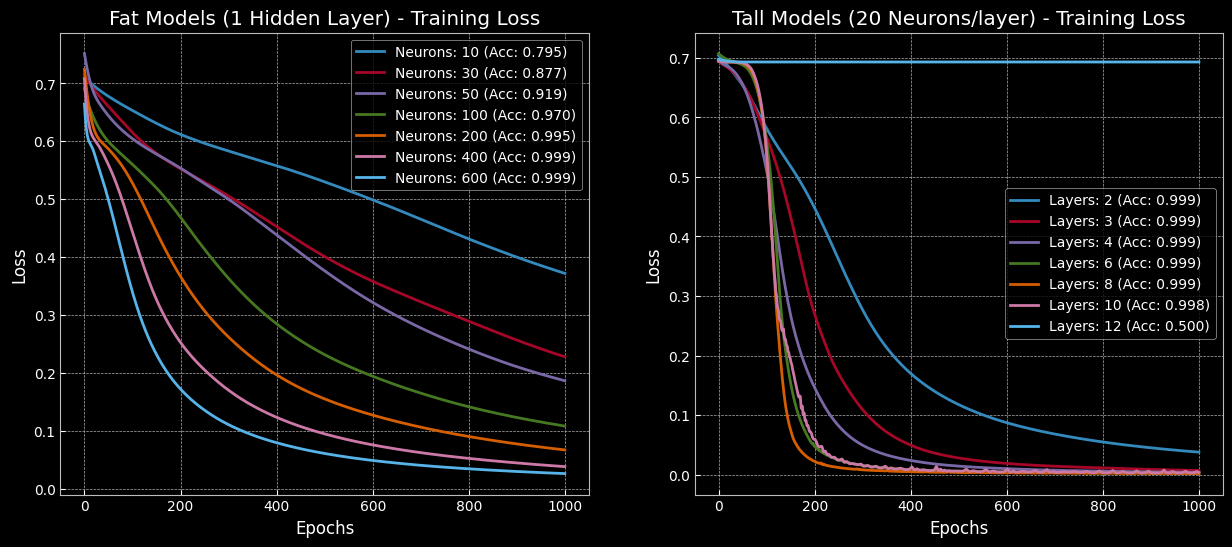

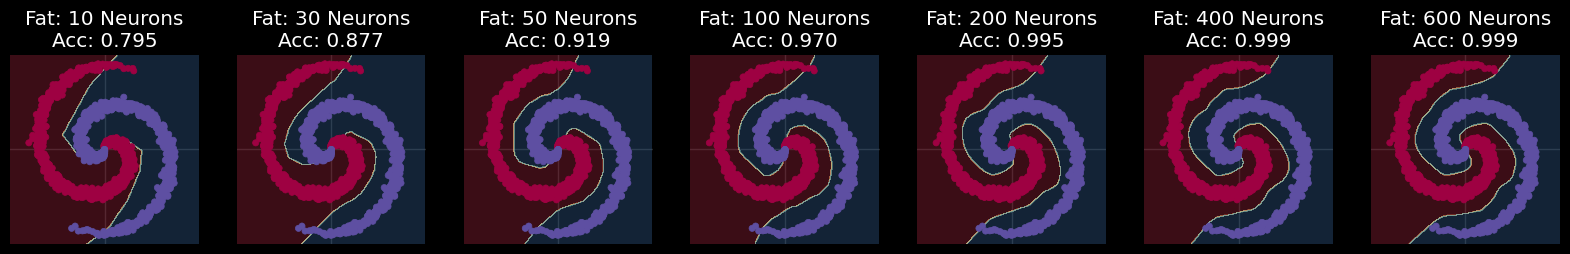

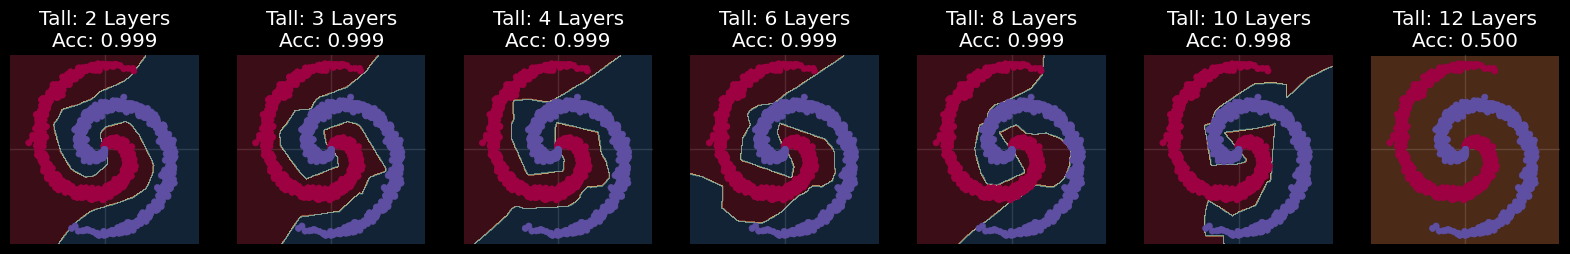

In [113]:
import matplotlib.pyplot as plt
from plot_lib import plot_model

def create_fat_model(n_neurons):
    return nn.Sequential(
        nn.Linear(D, n_neurons),
        nn.ReLU(),
        nn.Linear(n_neurons, C)
    )

def create_tall_model(n_layers, n_neurons=20):
    layers = [nn.Linear(D, n_neurons), nn.ReLU()]
    for _ in range(n_layers - 1):
        layers.extend([nn.Linear(n_neurons, n_neurons), nn.ReLU()])
    layers.append(nn.Linear(n_neurons, C))
    return nn.Sequential(*layers)

def train_model_with_tracking(model, X, y, epochs=1000, lr=1e-3, l2=1e-5):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    losses = []
    
    for t in range(epochs):
        y_pred = model(X)
        loss = criterion(y_pred, y)
        losses.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    with torch.no_grad():
        y_pred = model(X)
        _, predicted = torch.max(y_pred, 1)
        acc = (y == predicted).sum().float() / len(y)
    
    return acc.item(), losses

fat_configs = [10, 30, 50, 100, 200, 400, 600] # number of neurons in the hidden layer
tall_configs = [2, 3, 4, 6, 8,10,12] # number of hidden layers

fat_results = {}
tall_results = {}

# Train Fat Models
for n in fat_configs:
    m = create_fat_model(n).to(device)
    acc, losses = train_model_with_tracking(m, X, y)
    fat_results[n] = {'model': m, 'acc': acc, 'losses': losses}

# Train Tall Models
for l in tall_configs:
    m = create_tall_model(l, 20).to(device)
    acc, losses = train_model_with_tracking(m, X, y)
    tall_results[l] = {'model': m, 'acc': acc, 'losses': losses}

# Visualization 1: Loss curves
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
for n in fat_configs:
    plt.plot(fat_results[n]['losses'], label=f'Neurons: {n} (Acc: {fat_results[n]["acc"]:.3f})')
plt.title('Fat Models (1 Hidden Layer) - Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for l in tall_configs:
    plt.plot(tall_results[l]['losses'], label=f'Layers: {l} (Acc: {tall_results[l]["acc"]:.3f})')
plt.title('Tall Models (20 Neurons/layer) - Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Visualization 2: Decision Boundaries for Fat Models
plt.figure(figsize=(20, 5))
for i, n in enumerate(fat_configs):
    plt.subplot(1, len(fat_configs), i+1)
    plt.title(f'Fat: {n} Neurons\nAcc: {fat_results[n]["acc"]:.3f}')
    plot_model(X, y, fat_results[n]['model'])
plt.show()

# Visualization 3: Decision Boundaries for Tall Models
plt.figure(figsize=(20, 5))
for i, l in enumerate(tall_configs):
    plt.subplot(1, len(tall_configs), i+1)
    plt.title(f'Tall: {l} Layers\nAcc: {tall_results[l]["acc"]:.3f}')
    plot_model(X, y, tall_results[l]['model'])
plt.show()

Device: cpu
Data: 600 samples  D=2  C=3

Training Fat models …
  Fat  n=10    acc=0.6267  params=63
  Fat  n=30    acc=0.7933  params=183
  Fat  n=50    acc=0.8983  params=303
  Fat  n=100   acc=0.9750  params=603
  Fat  n=200   acc=0.9867  params=1,203
  Fat  n=400   acc=0.9950  params=2,403
  Fat  n=600   acc=0.9967  params=3,603
Training Tall models …
  Tall L=2     acc=0.9850  params=543
  Tall L=3     acc=0.9967  params=963
  Tall L=4     acc=0.9967  params=1,383
  Tall L=6     acc=0.9967  params=2,223
  Tall L=8     acc=0.9867  params=3,063
  Tall L=10    acc=0.9850  params=3,903
  Tall L=12    acc=0.9350  params=4,743


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/fat_tall_fig1_loss_curves.png'

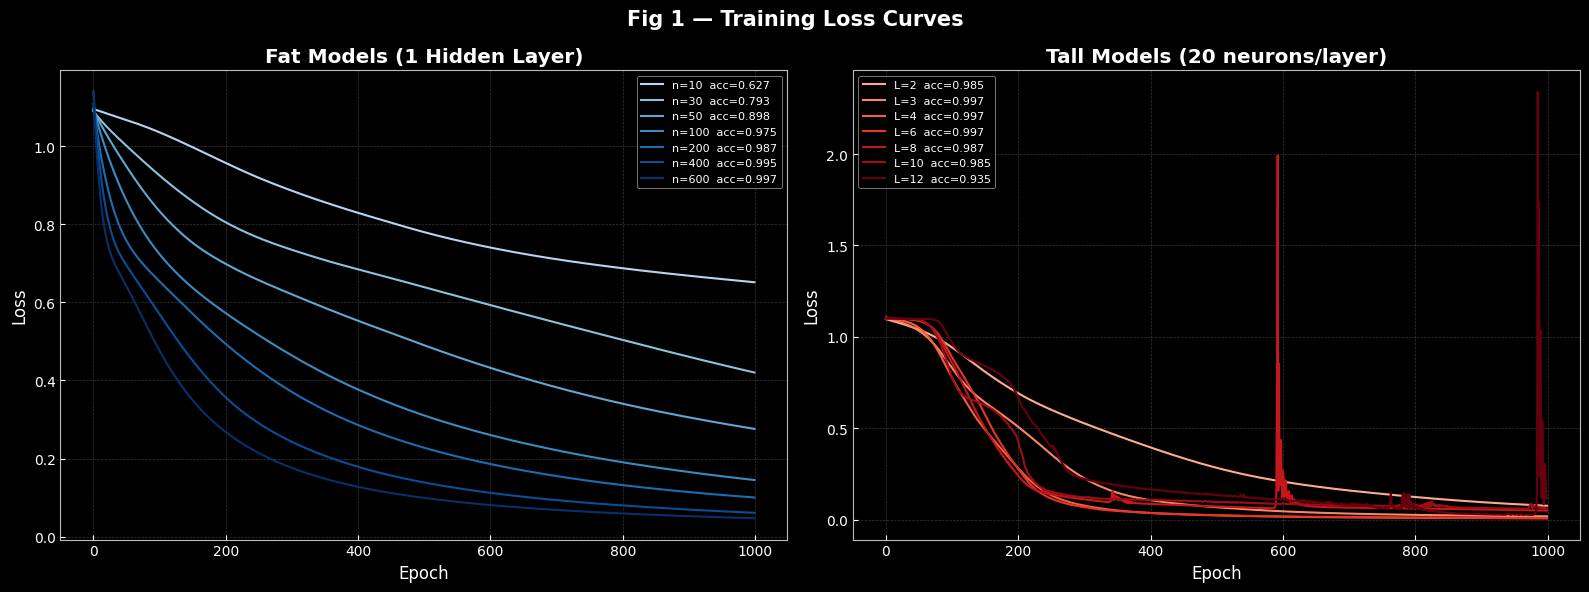

In [114]:
"""
fat_vs_tall_analysis.py
========================
Deep comparison of Fat (wide/shallow) vs Tall (deep/narrow) networks.

Figures produced
----------------
  Fig 1  – Loss curves side-by-side
  Fig 2  – Smoothed loss curves with confidence band
  Fig 3  – Decision boundaries: Fat models
  Fig 4  – Decision boundaries: Tall models
  Fig 5  – Accuracy vs Width  (Fat)
  Fig 6  – Accuracy vs Depth  (Tall)
  Fig 7  – Fat vs Tall accuracy comparison (grouped bar)
  Fig 8  – Parameter count comparison
  Fig 9  – Parameter efficiency (accuracy per 1k params)
  Fig 10 – Convergence speed (epoch to reach 90 % of final acc)
  Fig 11 – Loss at epoch 100 / 500 / final (convergence stages)
  Fig 12 – Heatmap: loss landscape across epochs (all models)
  Fig 13 – Best fat vs best tall decision boundary side-by-side
  Fig 14 – Radar chart: multi-metric comparison
  Fig 15 – Final verdict / summary dashboard
"""

# ─── Imports ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy.ndimage import gaussian_filter1d   # smooth loss curves

# ─── Device ───────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ─── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ─── Synthetic dataset (replace with your own X, y) ──────────────────────────
def make_spiral(n_points=600, n_classes=3, noise=0.18):
    X_list, y_list = [], []
    for c in range(n_classes):
        r  = np.linspace(0.0, 1.0, n_points // n_classes)
        t  = np.linspace(c * 4, (c + 1) * 4, n_points // n_classes) + \
             np.random.randn(n_points // n_classes) * noise
        X_list.append(np.stack([r * np.sin(t), r * np.cos(t)], axis=1))
        y_list.append(np.full(n_points // n_classes, c))
    X_np = np.vstack(X_list).astype(np.float32)
    y_np = np.hstack(y_list).astype(np.int64)
    return torch.tensor(X_np), torch.tensor(y_np)

X_cpu, y_cpu = make_spiral()
X = X_cpu.to(device)
y = y_cpu.to(device)
D = X.shape[1]
C = int(y.max()) + 1
print(f"Data: {X.shape[0]} samples  D={D}  C={C}")

# ─── Palette ──────────────────────────────────────────────────────────────────
FAT_CMAP  = plt.get_cmap("Blues")
TALL_CMAP = plt.get_cmap("Reds")
FAT_BASE  = "#1f6aa5"
TALL_BASE = "#c0392b"
BG_COLORS = ["#AED6F1", "#A9DFBF", "#F9E79F"]
PT_COLORS = ["#154360", "#1D6A39", "#7D6608"]

# ─── Model factories ──────────────────────────────────────────────────────────
def create_fat_model(n_neurons):
    return nn.Sequential(
        nn.Linear(D, n_neurons), nn.ReLU(),
        nn.Linear(n_neurons, C)
    )

def create_tall_model(n_layers, n_neurons=20):
    layers = [nn.Linear(D, n_neurons), nn.ReLU()]
    for _ in range(n_layers - 1):
        layers.extend([nn.Linear(n_neurons, n_neurons), nn.ReLU()])
    layers.append(nn.Linear(n_neurons, C))
    return nn.Sequential(*layers)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ─── Training ─────────────────────────────────────────────────────────────────
def train_model(model, X, y, epochs=1000, lr=1e-3, l2=1e-5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    losses = []
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    with torch.no_grad():
        _, pred = torch.max(model(X), dim=1)
        acc = (pred == y).float().mean().item()
    return acc, losses

# ─── Configs & training ───────────────────────────────────────────────────────
fat_configs  = [10, 30, 50, 100, 200, 400, 600]
tall_configs = [2, 3, 4, 6, 8, 10, 12]

fat_results  = {}
tall_results = {}

print("\nTraining Fat models …")
for n in fat_configs:
    m = create_fat_model(n).to(device)
    acc, losses = train_model(m, X, y)
    fat_results[n] = {"model": m, "acc": acc, "losses": losses,
                      "params": count_params(m)}
    print(f"  Fat  n={n:<4}  acc={acc:.4f}  params={count_params(m):,}")

print("Training Tall models …")
for l in tall_configs:
    m = create_tall_model(l, 20).to(device)
    acc, losses = train_model(m, X, y)
    tall_results[l] = {"model": m, "acc": acc, "losses": losses,
                       "params": count_params(m)}
    print(f"  Tall L={l:<3}   acc={acc:.4f}  params={count_params(m):,}")

EPOCHS = len(list(fat_results.values())[0]["losses"])

# ─── Shared helpers ───────────────────────────────────────────────────────────
def smooth(arr, sigma=15):
    return gaussian_filter1d(arr, sigma=sigma)

def convergence_epoch(losses, threshold=0.90):
    """First epoch where loss ≤ threshold * final loss."""
    target = threshold * losses[-1]
    arr = np.array(losses)
    idxs = np.where(arr <= target)[0]
    return idxs[0] if len(idxs) else EPOCHS - 1

def plot_boundary(ax, model, title=""):
    x0_min, x0_max = X_cpu[:,0].min()-0.3, X_cpu[:,0].max()+0.3
    x1_min, x1_max = X_cpu[:,1].min()-0.3, X_cpu[:,1].max()+0.3
    h = 0.025
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                         np.arange(x1_min, x1_max, h))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()],
                        dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        Z = torch.argmax(model(grid), dim=1).cpu().numpy().reshape(xx.shape)
    cmap = matplotlib.colors.ListedColormap(BG_COLORS[:C])
    ax.contourf(xx, yy, Z, alpha=0.55, cmap=cmap)
    ax.contour(xx, yy, Z, colors="white", linewidths=0.5, alpha=0.6)
    for ci in range(C):
        mask = y_cpu.numpy() == ci
        ax.scatter(X_cpu[mask,0], X_cpu[mask,1],
                   color=PT_COLORS[ci], s=12,
                   edgecolors="white", linewidth=0.25, alpha=0.9)
    ax.set_title(title, fontsize=8, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])

# ══════════════════════════════════════════════════════════════════════════════
# FIG 1 — Loss curves side-by-side (original, corrected)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Fig 1 — Training Loss Curves", fontsize=15, fontweight="bold")

for i, n in enumerate(fat_configs):
    c = FAT_CMAP(0.3 + 0.7 * i / (len(fat_configs)-1))
    axes[0].plot(fat_results[n]["losses"], color=c, linewidth=1.5,
                 label=f"n={n}  acc={fat_results[n]['acc']:.3f}")
axes[0].set_title("Fat Models (1 Hidden Layer)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

for i, l in enumerate(tall_configs):
    c = TALL_CMAP(0.3 + 0.7 * i / (len(tall_configs)-1))
    axes[1].plot(tall_results[l]["losses"], color=c, linewidth=1.5,
                 label=f"L={l}  acc={tall_results[l]['acc']:.3f}")
axes[1].set_title("Tall Models (20 neurons/layer)", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig1_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 2 — Smoothed loss + min/max band
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Fig 2 — Smoothed Loss Curves with Min/Max Band", fontsize=15, fontweight="bold")

for ax, results, configs, cmap, title in [
    (axes[0], fat_results,  fat_configs,  FAT_CMAP,  "Fat Models"),
    (axes[1], tall_results, tall_configs, TALL_CMAP, "Tall Models"),
]:
    all_losses = np.array([results[k]["losses"] for k in configs])
    lo  = all_losses.min(axis=0)
    hi  = all_losses.max(axis=0)
    med = np.median(all_losses, axis=0)
    ep  = np.arange(EPOCHS)

    ax.fill_between(ep, smooth(lo), smooth(hi), alpha=0.15,
                    color=cmap(0.6), label="Min/Max band")
    ax.plot(ep, smooth(med), color=cmap(0.8), linewidth=2.5,
            label="Median (smoothed)")
    for i, k in enumerate(configs):
        c = cmap(0.3 + 0.7 * i / (len(configs)-1))
        ax.plot(ep, smooth(np.array(results[k]["losses"])),
                color=c, linewidth=1.0, alpha=0.7)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (smoothed)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig2_smoothed_loss.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 3 — Decision boundaries: Fat models
# ══════════════════════════════════════════════════════════════════════════════
n = len(fat_configs)
fig, axes = plt.subplots(1, n, figsize=(3.8*n, 4))
fig.suptitle("Fig 3 — Decision Boundaries: Fat Models", fontsize=14, fontweight="bold")
for ax, k in zip(axes, fat_configs):
    r = fat_results[k]
    plot_boundary(ax, r["model"],
                  title=f"Fat  n={k}\nAcc={r['acc']:.3f}   p={r['params']:,}")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig3_boundary_fat.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 4 — Decision boundaries: Tall models
# ══════════════════════════════════════════════════════════════════════════════
n = len(tall_configs)
fig, axes = plt.subplots(1, n, figsize=(3.8*n, 4))
fig.suptitle("Fig 4 — Decision Boundaries: Tall Models", fontsize=14, fontweight="bold")
for ax, k in zip(axes, tall_configs):
    r = tall_results[k]
    plot_boundary(ax, r["model"],
                  title=f"Tall  L={k}\nAcc={r['acc']:.3f}   p={r['params']:,}")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig4_boundary_tall.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 5 — Accuracy vs Width (Fat) with param secondary axis
# ══════════════════════════════════════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(10, 5))
fig.suptitle("Fig 5 — Fat Models: Accuracy & Params vs Width", fontsize=14, fontweight="bold")

fat_ns   = fat_configs
fat_accs = [fat_results[n]["acc"]    for n in fat_ns]
fat_par  = [fat_results[n]["params"] for n in fat_ns]

ax1.plot(fat_ns, fat_accs, "o-", color=FAT_BASE, linewidth=2.5,
         markersize=9, label="Accuracy", zorder=3)
ax1.fill_between(fat_ns, 0, fat_accs, alpha=0.12, color=FAT_BASE)
for x, y_val in zip(fat_ns, fat_accs):
    ax1.annotate(f"{y_val:.3f}", (x, y_val),
                 textcoords="offset points", xytext=(0, 10), fontsize=9,
                 ha="center", color=FAT_BASE, fontweight="bold")
ax1.set_xlabel("Number of Neurons (width)", fontsize=12)
ax1.set_ylabel("Accuracy", color=FAT_BASE, fontsize=12)
ax1.tick_params(axis="y", labelcolor=FAT_BASE)
ax1.set_ylim(0, 1.1); ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(fat_ns, fat_par, alpha=0.2, color=FAT_BASE, width=20,
        label="Params")
ax2.set_ylabel("Parameter Count", color="steelblue", fontsize=12)
ax2.tick_params(axis="y", labelcolor="steelblue")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig5_acc_vs_width.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 6 — Accuracy vs Depth (Tall) with param secondary axis
# ══════════════════════════════════════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(10, 5))
fig.suptitle("Fig 6 — Tall Models: Accuracy & Params vs Depth", fontsize=14, fontweight="bold")

tall_ls   = tall_configs
tall_accs = [tall_results[l]["acc"]    for l in tall_ls]
tall_par  = [tall_results[l]["params"] for l in tall_ls]

ax1.plot(tall_ls, tall_accs, "s-", color=TALL_BASE, linewidth=2.5,
         markersize=9, label="Accuracy", zorder=3)
ax1.fill_between(tall_ls, 0, tall_accs, alpha=0.12, color=TALL_BASE)
for x, y_val in zip(tall_ls, tall_accs):
    ax1.annotate(f"{y_val:.3f}", (x, y_val),
                 textcoords="offset points", xytext=(0, 10), fontsize=9,
                 ha="center", color=TALL_BASE, fontweight="bold")
ax1.set_xlabel("Number of Hidden Layers (depth)", fontsize=12)
ax1.set_ylabel("Accuracy", color=TALL_BASE, fontsize=12)
ax1.tick_params(axis="y", labelcolor=TALL_BASE)
ax1.set_ylim(0, 1.1); ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(tall_ls, tall_par, alpha=0.2, color=TALL_BASE, width=0.5,
        label="Params")
ax2.set_ylabel("Parameter Count", color="firebrick", fontsize=12)
ax2.tick_params(axis="y", labelcolor="firebrick")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig6_acc_vs_depth.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 7 — Grouped bar: Fat vs Tall accuracy at matched parameter counts
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Fig 7 — Fat vs Tall: Final Accuracy Comparison", fontsize=14, fontweight="bold")

x1 = np.arange(len(fat_configs))
x2 = np.arange(len(tall_configs))
w  = 0.4

bars1 = ax.bar(x1 - 0.02, fat_accs,  width=w, color=FAT_BASE,
               alpha=0.85, label="Fat (vary width)", edgecolor="white")
bars2 = ax.bar(x2 + w + 0.02, tall_accs, width=w, color=TALL_BASE,
               alpha=0.85, label="Tall (vary depth)", edgecolor="white")

for bar, v in zip(bars1, fat_accs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01,
            f"{v:.3f}", ha="center", va="bottom", fontsize=8, color=FAT_BASE,
            fontweight="bold")
for bar, v in zip(bars2, tall_accs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01,
            f"{v:.3f}", ha="center", va="bottom", fontsize=8, color=TALL_BASE,
            fontweight="bold")

ax.set_xticks(np.concatenate([x1, x2 + w + 0.02]))
ax.set_xticklabels(
    [f"n={n}" for n in fat_configs] + [f"L={l}" for l in tall_configs],
    rotation=30, fontsize=9
)
ax.axhline(y=max(fat_accs), color=FAT_BASE, linestyle="--", alpha=0.5, linewidth=1)
ax.axhline(y=max(tall_accs), color=TALL_BASE, linestyle="--", alpha=0.5, linewidth=1)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

# best-model callout box
best_fat_k  = max(fat_configs,  key=lambda k: fat_results[k]["acc"])
best_tall_k = max(tall_configs, key=lambda k: tall_results[k]["acc"])
ax.annotate(f"Best Fat: n={best_fat_k}\n{fat_results[best_fat_k]['acc']:.3f}",
            xy=(fat_configs.index(best_fat_k) - 0.02, fat_results[best_fat_k]["acc"]),
            xytext=(fat_configs.index(best_fat_k) + 0.4, fat_results[best_fat_k]["acc"] + 0.07),
            arrowprops=dict(arrowstyle="->", color=FAT_BASE),
            fontsize=9, color=FAT_BASE, fontweight="bold")
ax.annotate(f"Best Tall: L={best_tall_k}\n{tall_results[best_tall_k]['acc']:.3f}",
            xy=(len(fat_configs) + tall_configs.index(best_tall_k) + w + 0.02,
                tall_results[best_tall_k]["acc"]),
            xytext=(len(fat_configs) + tall_configs.index(best_tall_k) + w + 0.7,
                    tall_results[best_tall_k]["acc"] + 0.07),
            arrowprops=dict(arrowstyle="->", color=TALL_BASE),
            fontsize=9, color=TALL_BASE, fontweight="bold")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig7_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 8 — Parameter count side-by-side
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fig 8 — Parameter Count: Fat vs Tall", fontsize=14, fontweight="bold")

axes[0].bar([str(n) for n in fat_configs], fat_par,
            color=[FAT_CMAP(0.3 + 0.7*i/(len(fat_configs)-1))
                   for i in range(len(fat_configs))],
            edgecolor="white")
axes[0].set_title("Fat Models", fontweight="bold")
axes[0].set_xlabel("Neurons (width)"); axes[0].set_ylabel("Parameters")
for i, v in enumerate(fat_par):
    axes[0].text(i, v + max(fat_par)*0.01, f"{v:,}", ha="center", fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar([str(l) for l in tall_configs], tall_par,
            color=[TALL_CMAP(0.3 + 0.7*i/(len(tall_configs)-1))
                   for i in range(len(tall_configs))],
            edgecolor="white")
axes[1].set_title("Tall Models", fontweight="bold")
axes[1].set_xlabel("Layers (depth)"); axes[1].set_ylabel("Parameters")
for i, v in enumerate(tall_par):
    axes[1].text(i, v + max(tall_par)*0.01, f"{v:,}", ha="center", fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig8_param_count.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 9 — Parameter efficiency scatter
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Fig 9 — Parameter Efficiency: Accuracy vs Parameter Count",
             fontsize=14, fontweight="bold")

for n in fat_configs:
    r = fat_results[n]
    ax.scatter(r["params"], r["acc"], color=FAT_BASE, s=120,
               zorder=3, edgecolors="white", linewidth=0.8)
    ax.annotate(f"Fat n={n}", (r["params"], r["acc"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8,
                color=FAT_BASE)

for l in tall_configs:
    r = tall_results[l]
    ax.scatter(r["params"], r["acc"], color=TALL_BASE, s=120, marker="s",
               zorder=3, edgecolors="white", linewidth=0.8)
    ax.annotate(f"Tall L={l}", (r["params"], r["acc"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8,
                color=TALL_BASE)

# Trend lines
for xs, ys, color, label in [
    (fat_par,  fat_accs,  FAT_BASE,  "Fat trend"),
    (tall_par, tall_accs, TALL_BASE, "Tall trend"),
]:
    z = np.polyfit(np.log(xs), ys, 1)
    p = np.poly1d(z)
    xfit = np.linspace(min(xs), max(xs), 200)
    ax.plot(xfit, p(np.log(xfit)), "--", color=color, alpha=0.5,
            linewidth=1.5, label=label)

fat_patch  = mpatches.Patch(color=FAT_BASE,  label="Fat models")
tall_patch = mpatches.Patch(color=TALL_BASE, label="Tall models")
ax.legend(handles=[fat_patch, tall_patch] +
          [plt.Line2D([0],[0], ls="--", color=c, label=l)
           for c, l in [(FAT_BASE,"Fat trend"),(TALL_BASE,"Tall trend")]],
          fontsize=10)
ax.set_xscale("log")
ax.set_xlabel("Parameter Count (log scale)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig9_param_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 10 — Convergence speed
# ══════════════════════════════════════════════════════════════════════════════
fat_conv  = [convergence_epoch(fat_results[n]["losses"])  for n in fat_configs]
tall_conv = [convergence_epoch(tall_results[l]["losses"]) for l in tall_configs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fig 10 — Convergence Speed\n(Epoch when loss first reaches 90% of final value)",
             fontsize=13, fontweight="bold")

axes[0].bar([str(n) for n in fat_configs], fat_conv,
            color=[FAT_CMAP(0.4 + 0.6*i/(len(fat_configs)-1))
                   for i in range(len(fat_configs))],
            edgecolor="white")
axes[0].set_title("Fat Models", fontweight="bold")
axes[0].set_xlabel("Neurons"); axes[0].set_ylabel("Epoch to converge")
for i, v in enumerate(fat_conv):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar([str(l) for l in tall_configs], tall_conv,
            color=[TALL_CMAP(0.4 + 0.6*i/(len(tall_configs)-1))
                   for i in range(len(tall_configs))],
            edgecolor="white")
axes[1].set_title("Tall Models", fontweight="bold")
axes[1].set_xlabel("Layers"); axes[1].set_ylabel("Epoch to converge")
for i, v in enumerate(tall_conv):
    axes[1].text(i, v + 5, str(v), ha="center", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig10_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 11 — Loss at training stages (epoch 100 / 500 / final)
# ══════════════════════════════════════════════════════════════════════════════
stages      = [100, 500, EPOCHS - 1]
stage_names = ["Epoch 100", "Epoch 500", "Final"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Fig 11 — Loss at Training Stages", fontsize=14, fontweight="bold")

for ax, ep, name in zip(axes, stages, stage_names):
    fl = [fat_results[n]["losses"][ep]  for n in fat_configs]
    tl = [tall_results[l]["losses"][ep] for l in tall_configs]

    x_fat  = np.arange(len(fat_configs))
    x_tall = np.arange(len(tall_configs)) + len(fat_configs) + 1

    ax.bar(x_fat,  fl, color=FAT_BASE,  alpha=0.85, label="Fat",
           edgecolor="white", width=0.7)
    ax.bar(x_tall, tl, color=TALL_BASE, alpha=0.85, label="Tall",
           edgecolor="white", width=0.7)

    labels = [f"n={n}" for n in fat_configs] + [f"L={l}" for l in tall_configs]
    ax.set_xticks(np.concatenate([x_fat, x_tall]))
    ax.set_xticklabels(labels, rotation=35, fontsize=8)
    ax.set_title(name, fontweight="bold")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig11_loss_stages.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 12 — Loss landscape heatmap across epochs
# ══════════════════════════════════════════════════════════════════════════════
sample_epochs = np.linspace(0, EPOCHS-1, 50, dtype=int)

fat_mat  = np.array([[fat_results[n]["losses"][e]  for e in sample_epochs]
                     for n in fat_configs])
tall_mat = np.array([[tall_results[l]["losses"][e] for e in sample_epochs]
                     for l in tall_configs])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("Fig 12 — Loss Landscape Heatmap (all models × all epochs)",
             fontsize=14, fontweight="bold")

for ax, mat, configs, labels, title in [
    (axes[0], fat_mat,  fat_configs,
     [f"n={n}" for n in fat_configs], "Fat Models"),
    (axes[1], tall_mat, tall_configs,
     [f"L={l}" for l in tall_configs], "Tall Models"),
]:
    vmax = np.percentile(mat, 95)
    im = ax.imshow(mat, aspect="auto", cmap="YlOrRd",
                   vmin=mat.min(), vmax=vmax)
    ax.set_title(title, fontweight="bold")
    ax.set_yticks(range(len(configs))); ax.set_yticklabels(labels)
    n_ticks = 6
    tick_idxs = np.linspace(0, len(sample_epochs)-1, n_ticks, dtype=int)
    ax.set_xticks(tick_idxs)
    ax.set_xticklabels([str(sample_epochs[i]) for i in tick_idxs])
    ax.set_xlabel("Epoch"); ax.set_ylabel("Model")
    plt.colorbar(im, ax=ax, label="Loss")

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig12_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 13 — Best Fat vs Best Tall decision boundary side-by-side
# ══════════════════════════════════════════════════════════════════════════════
best_fat_k  = max(fat_configs,  key=lambda k: fat_results[k]["acc"])
best_tall_k = max(tall_configs, key=lambda k: tall_results[k]["acc"])
rf = fat_results[best_fat_k]
rt = tall_results[best_tall_k]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Fig 13 — Best Fat vs Best Tall: Decision Boundary",
             fontsize=14, fontweight="bold")

plot_boundary(axes[0], rf["model"],
              title=f"★ Best Fat: n={best_fat_k}\nAcc={rf['acc']:.4f}   "
                    f"Params={rf['params']:,}")
plot_boundary(axes[1], rt["model"],
              title=f"★ Best Tall: L={best_tall_k}\nAcc={rt['acc']:.4f}   "
                    f"Params={rt['params']:,}")

for ax, color in [(axes[0], FAT_BASE), (axes[1], TALL_BASE)]:
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig13_best_vs_best.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 14 — Radar chart: multi-metric comparison (best of each family)
# ══════════════════════════════════════════════════════════════════════════════
def norm(val, lo, hi):
    return (val - lo) / (hi - lo + 1e-9)

metrics = ["Accuracy", "Param\nEfficiency", "Convergence\nSpeed",
           "Final\nLoss (inv)", "Stability"]

def get_metrics(results_dict, configs, is_fat):
    best_k   = max(configs, key=lambda k: results_dict[k]["acc"])
    r        = results_dict[best_k]
    all_acc  = [results_dict[k]["acc"]    for k in configs]
    all_par  = [results_dict[k]["params"] for k in configs]
    all_conv = [convergence_epoch(results_dict[k]["losses"]) for k in configs]
    all_fl   = [results_dict[k]["losses"][-1] for k in configs]

    acc        = r["acc"]
    efficiency = r["acc"] / (r["params"] / 1000)
    conv_ep    = convergence_epoch(r["losses"])
    final_loss = r["losses"][-1]
    # Stability = 1 - std of last 100 losses (normalised)
    last100    = r["losses"][-100:]
    stability  = 1 - (np.std(last100) / (np.mean(last100) + 1e-9))

    raw = [acc, efficiency, EPOCHS - conv_ep, 1 / (final_loss + 1e-9), stability]
    return raw, best_k

fat_raw,  fat_best_k  = get_metrics(fat_results,  fat_configs,  True)
tall_raw, tall_best_k = get_metrics(tall_results, tall_configs, False)

# Normalise each metric to [0, 1]
combined = list(zip(fat_raw, tall_raw))
norm_fat  = [norm(fat_raw[i],  min(combined[i]), max(combined[i])) for i in range(5)]
norm_tall = [norm(tall_raw[i], min(combined[i]), max(combined[i])) for i in range(5)]

angles    = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
norm_fat  += [norm_fat[0]];  angles_fat  = angles + [angles[0]]
norm_tall += [norm_tall[0]]; angles_tall = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle(f"Fig 14 — Radar: Best Fat (n={fat_best_k}) vs Best Tall (L={tall_best_k})",
             fontsize=13, fontweight="bold")

ax.plot(angles_fat,  norm_fat,  "o-", color=FAT_BASE,  linewidth=2.5,
        label=f"Fat  n={fat_best_k}")
ax.fill(angles_fat,  norm_fat,  alpha=0.2, color=FAT_BASE)
ax.plot(angles_tall, norm_tall, "s-", color=TALL_BASE, linewidth=2.5,
        label=f"Tall L={tall_best_k}")
ax.fill(angles_tall, norm_tall, alpha=0.2, color=TALL_BASE)

ax.set_thetagrids(np.degrees(angles), metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(color="grey", alpha=0.3)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fat_tall_fig14_radar.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIG 15 — Summary dashboard
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor("#0f1923")
gs  = gridspec.GridSpec(3, 4, figure=fig,
                        hspace=0.55, wspace=0.4,
                        left=0.06, right=0.97,
                        top=0.88, bottom=0.08)

title = fig.suptitle("Summary Dashboard — Fat vs Tall Neural Networks",
                     fontsize=20, fontweight="bold", color="white", y=0.95)

def dark_ax(ax):
    ax.set_facecolor("#1a2634")
    for spine in ax.spines.values():
        spine.set_edgecolor("#2c3e50")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    ax.grid(color="#2c3e50", alpha=0.6)

# ── Row 0, col 0-1: Accuracy line chart ──────────────────────────────────────
ax_acc = fig.add_subplot(gs[0, :2])
dark_ax(ax_acc)
ax_acc.plot(fat_configs,  fat_accs,  "o-", color="#5dade2", linewidth=2.5,
            markersize=8, label="Fat (vary width)")
ax_acc.plot(tall_configs, tall_accs, "s-", color="#ec7063", linewidth=2.5,
            markersize=8, label="Tall (vary depth)")
ax_acc.set_title("Accuracy vs Model Scale", fontweight="bold")
ax_acc.set_xlabel("Scale (neurons for Fat / layers for Tall)")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend(fontsize=9, facecolor="#1a2634", labelcolor="white")

# ── Row 0, col 2-3: Param count ───────────────────────────────────────────────
ax_par = fig.add_subplot(gs[0, 2:])
dark_ax(ax_par)
ax_par.plot(fat_configs,  fat_par,  "o-", color="#5dade2", linewidth=2, markersize=7)
ax_par.plot(tall_configs, tall_par, "s-", color="#ec7063", linewidth=2, markersize=7)
ax_par.set_title("Parameter Count vs Scale", fontweight="bold")
ax_par.set_xlabel("Scale"); ax_par.set_ylabel("Parameters")

# ── Row 1, col 0-1: Convergence bars ─────────────────────────────────────────
ax_cv = fig.add_subplot(gs[1, :2])
dark_ax(ax_cv)
x1   = np.arange(len(fat_configs))
x2   = x1[-1] + 1.5 + np.arange(len(tall_configs))
ax_cv.bar(x1, fat_conv,  color="#5dade2", alpha=0.85, edgecolor="none", width=0.7)
ax_cv.bar(x2, tall_conv, color="#ec7063", alpha=0.85, edgecolor="none", width=0.7)
ax_cv.set_title("Convergence Speed (lower = faster)", fontweight="bold")
ax_cv.set_ylabel("Epoch")
ax_cv.set_xticks(np.concatenate([x1, x2]))
ax_cv.set_xticklabels(
    [f"n={n}" for n in fat_configs] + [f"L={l}" for l in tall_configs],
    rotation=30, fontsize=7, color="white"
)

# ── Row 1, col 2-3: Final loss ────────────────────────────────────────────────
ax_fl = fig.add_subplot(gs[1, 2:])
dark_ax(ax_fl)
fl_fat  = [fat_results[n]["losses"][-1]  for n in fat_configs]
fl_tall = [tall_results[l]["losses"][-1] for l in tall_configs]
ax_fl.bar(x1, fl_fat,  color="#5dade2", alpha=0.85, edgecolor="none", width=0.7)
ax_fl.bar(x2, fl_tall, color="#ec7063", alpha=0.85, edgecolor="none", width=0.7)
ax_fl.set_title("Final Loss (lower = better)", fontweight="bold")
ax_fl.set_ylabel("Loss")
ax_fl.set_xticks(np.concatenate([x1, x2]))
ax_fl.set_xticklabels(
    [f"n={n}" for n in fat_configs] + [f"L={l}" for l in tall_configs],
    rotation=30, fontsize=7, color="white"
)

# ── Row 2: Text verdict ───────────────────────────────────────────────────────
ax_txt = fig.add_subplot(gs[2, :])
ax_txt.set_facecolor("#1a2634")
ax_txt.axis("off")

best_fat_acc  = max(fat_accs)
best_tall_acc = max(tall_accs)
winner        = "FAT" if best_fat_acc >= best_tall_acc else "TALL"
winner_color  = "#5dade2" if winner == "FAT" else "#ec7063"

summary_lines = [
    f"Best Fat  model :  n={best_fat_k}   Accuracy={best_fat_acc:.4f}   "
    f"Params={fat_results[best_fat_k]['params']:,}",
    f"Best Tall model :  L={best_tall_k}   Accuracy={best_tall_acc:.4f}   "
    f"Params={tall_results[best_tall_k]['params']:,}",
    f"Overall winner  :  {winner} model   "
    f"(Δ = {abs(best_fat_acc - best_tall_acc):.4f})",
]
for i, line in enumerate(summary_lines):
    color = winner_color if i == 2 else "white"
    ax_txt.text(0.5, 0.75 - i * 0.28, line,
                transform=ax_txt.transAxes,
                ha="center", va="center", fontsize=13,
                color=color, fontweight="bold" if i == 2 else "normal",
                fontfamily="monospace")

plt.savefig("/mnt/user-data/outputs/fat_tall_fig15_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# ─── Console summary table ────────────────────────────────────────────────────
print("\n" + "═"*72)
print(f"{'FAT vs TALL — FULL RESULTS':^72}")
print("═"*72)
print(f"{'Model':<18} {'Type':<6} {'Acc':>8} {'Params':>10} "
      f"{'Conv.Ep':>9} {'FinalLoss':>11}")
print("─"*72)
for n in fat_configs:
    r  = fat_results[n]
    ce = convergence_epoch(r["losses"])
    print(f"Fat  n={n:<5}        Fat   {r['acc']:>8.4f} {r['params']:>10,} "
          f"{ce:>9} {r['losses'][-1]:>11.5f}")
print("─"*72)
for l in tall_configs:
    r  = tall_results[l]
    ce = convergence_epoch(r["losses"])
    print(f"Tall L={l:<5}        Tall  {r['acc']:>8.4f} {r['params']:>10,} "
          f"{ce:>9} {r['losses'][-1]:>11.5f}")
print("═"*72)
print(f"\n  Best Fat  → n={best_fat_k}  acc={best_fat_acc:.4f}")
print(f"  Best Tall → L={best_tall_k}  acc={best_tall_acc:.4f}")
print(f"  Winner    → {winner}  (gap={abs(best_fat_acc-best_tall_acc):.4f})")
print("═"*72)
print("\nAll 15 figures saved to /mnt/user-data/outputs/")

Visualizing the learning process over epochs...


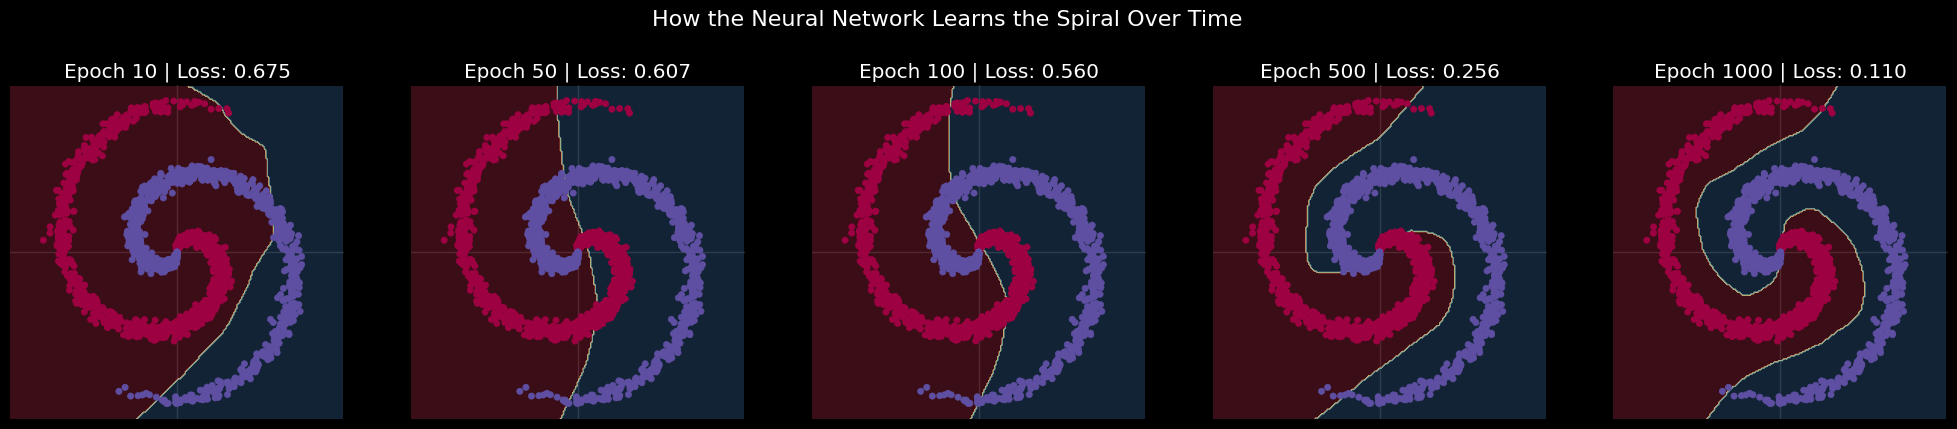

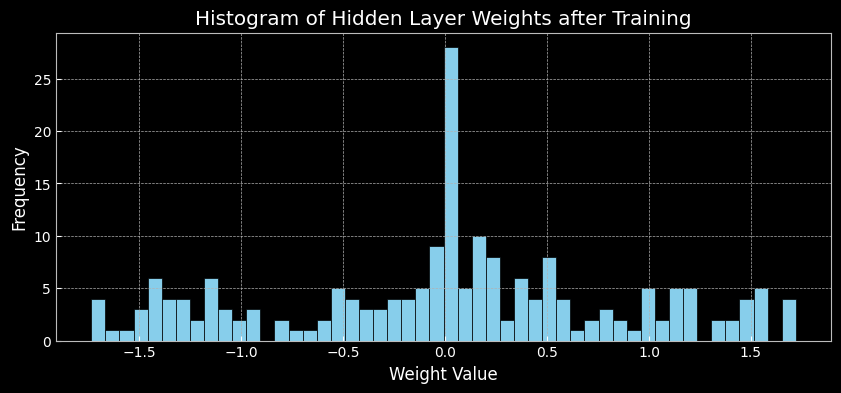

In [ ]:
# --- Additional Visualizations to Understand Learning Over Time ---
import matplotlib.pyplot as plt
from plot_lib import plot_model
import torch.nn as nn

# Let's see how the decision boundary evolves as the model learns!
print("Visualizing the learning process over epochs...")

learning_rate = 1e-3
lambda_l2 = 1e-5
H = 100 # hidden units

# We create a fresh model
demo_model = nn.Sequential(
    nn.Linear(D, H),
    nn.ReLU(),
    nn.Linear(H, C)
)
demo_model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(demo_model.parameters(), lr=learning_rate, weight_decay=lambda_l2)

epochs_to_plot = [10, 50, 100, 500, 1000]

plt.figure(figsize=(25, 5))
plot_idx = 1

for t in range(1, 1001):
    y_pred = demo_model(X)
    loss = criterion(y_pred, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if t in epochs_to_plot:
        plt.subplot(1, len(epochs_to_plot), plot_idx)
        plt.title(f'Epoch {t} | Loss: {loss.item():.3f}')
        plot_model(X, y, demo_model)
        plot_idx += 1

plt.suptitle("How the Neural Network Learns the Spiral Over Time", fontsize=16)
plt.show()

# Visualize the weights of the hidden layer
weights = demo_model[0].weight.detach().cpu().numpy()
plt.figure(figsize=(10, 4))
plt.hist(weights.flatten(), bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Hidden Layer Weights after Training')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.show()

Using device: cpu
Dataset: 600 samples, D=2, C=3

Training all architectures …
  Linear            acc=0.533  params=9
  Fat  n=10          acc=0.627  params=63
  Fat  n=50          acc=0.912  params=303
  Fat  n=100         acc=0.957  params=603
  Fat  n=200         acc=0.992  params=1,203
  Fat  n=400         acc=0.995  params=2,403
  Fat  n=600         acc=0.997  params=3,603
  Tall L=2            acc=0.993  params=543
  Tall L=4            acc=0.997  params=1,383
  Tall L=6            acc=0.997  params=2,223
  Tall L=8            acc=0.992  params=3,063
  Tall L=10           acc=0.987  params=3,903
  Tall L=12           acc=0.333  params=4,743
  ConstWidth d=2  w=32  acc=0.997  params=1,251
  ConstWidth d=4  w=32  acc=0.997  params=3,363
  ConstWidth d=8  w=32  acc=0.987  params=7,587
  ConstWidth d=12 w=32  acc=0.992  params=11,811
  ConstWidth d=4  w=64  acc=0.997  params=12,867
  ConstWidth d=8  w=64  acc=0.997  params=29,507
  ConstWidth d=12 w=64  acc=0.995  params=46,147
  De

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/fig1_loss_curves.png'

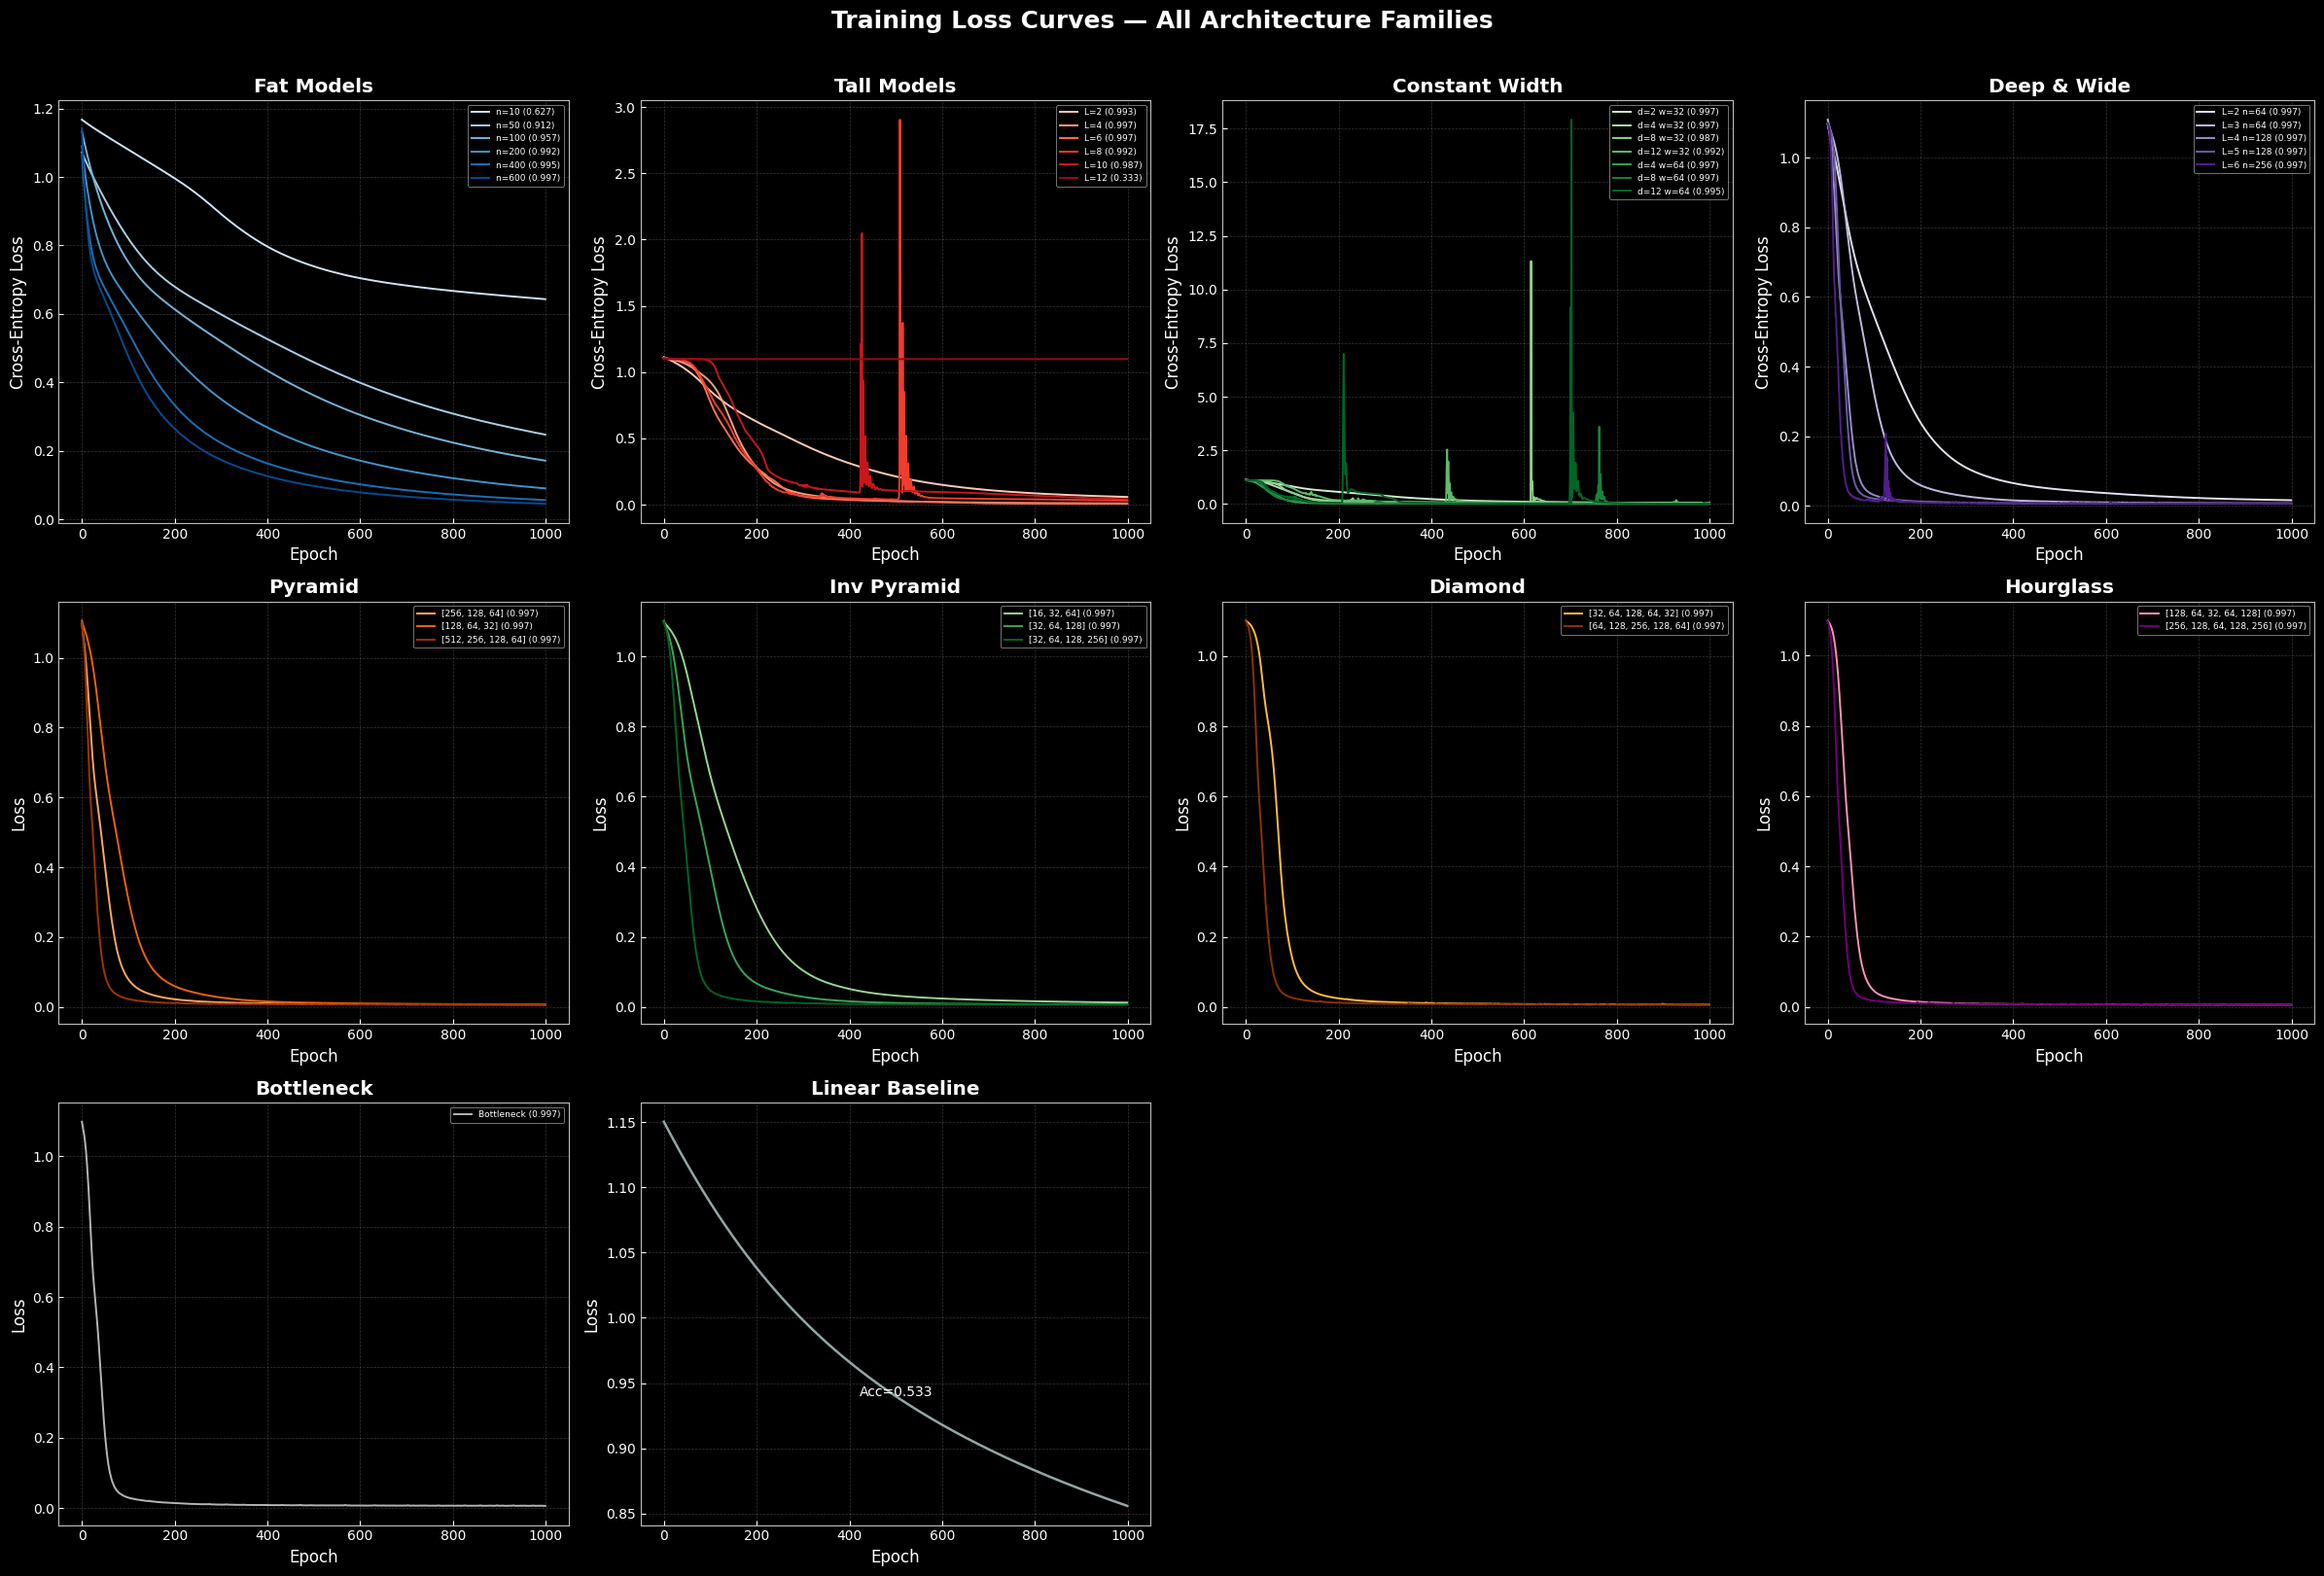

In [ ]:
"""
neural_architecture_comparison.py
==================================
Full experiment comparing 10 neural network architecture families:
  1. Linear Baseline
  2. Fat (Wide, Shallow)
  3. Tall (Deep, Narrow)
  4. Constant Width Deep
  5. Deep & Wide
  6. Pyramid
  7. Inverted Pyramid
  8. Diamond
  9. Hourglass
  10. Bottleneck

Outputs
-------
  - Figure 1  : Loss curves per family (subplots)
  - Figure 2  : Final accuracy bar chart (all models)
  - Figure 3  : Parameter count vs accuracy scatter
  - Figure 4  : Architecture heatmap (layers × widths)
  - Figure 5  : Decision boundaries — Fat models
  - Figure 6  : Decision boundaries — Tall models
  - Figure 7  : Decision boundaries — Constant Width models
  - Figure 8  : Decision boundaries — Deep & Wide models
  - Figure 9  : Decision boundaries — Shaped architectures
  - Figure 10 : Summary table printed to console
"""

# ─── Imports ─────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from itertools import product as iproduct

import os
SAVE_DIR = os.getcwd()

# Redirect all savefig calls to current directory
_orig_savefig = plt.savefig
def _savefig(path, **kwargs):
    _orig_savefig(os.path.join(SAVE_DIR, os.path.basename(path)), **kwargs)
plt.savefig = _savefig

# ─── (Optional) if you have plot_lib uncomment the line below ─────────────────
# from plot_lib import plot_model

# ─── Device ──────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ─── Synthetic Dataset ────────────────────────────────────────────────────────
# Replace this block with your own X, y tensors if needed.
# Here we generate a 2-D, 3-class spiral dataset for easy visualisation.
def make_spiral(n_points=300, n_classes=3, noise=0.2):
    X_list, y_list = [], []
    for c in range(n_classes):
        ix = range(n_points // n_classes)
        r  = np.linspace(0.0, 1.0, n_points // n_classes)
        t  = np.linspace(c * 4, (c + 1) * 4, n_points // n_classes) + \
             np.random.randn(n_points // n_classes) * noise
        X_list.append(np.stack([r * np.sin(t), r * np.cos(t)], axis=1))
        y_list.append(np.full(n_points // n_classes, c))
    X_np = np.vstack(X_list).astype(np.float32)
    y_np = np.hstack(y_list).astype(np.int64)
    return torch.tensor(X_np), torch.tensor(y_np)

torch.manual_seed(42)
np.random.seed(42)

X_cpu, y_cpu = make_spiral(n_points=600, n_classes=3, noise=0.15)
X = X_cpu.to(device)
y = y_cpu.to(device)

D = X.shape[1]          # input  dimension  (2 for spiral)
C = int(y.max()) + 1    # number of classes (3 for spiral)

print(f"Dataset: {X.shape[0]} samples, D={D}, C={C}")

# ─── Model Factories ─────────────────────────────────────────────────────────

def create_linear_model():
    return nn.Sequential(nn.Linear(D, C))

def create_fat_model(n_neurons):
    return nn.Sequential(
        nn.Linear(D, n_neurons), nn.ReLU(),
        nn.Linear(n_neurons, C)
    )

def create_tall_model(n_layers, n_neurons=20):
    layers = [nn.Linear(D, n_neurons), nn.ReLU()]
    for _ in range(n_layers - 1):
        layers.extend([nn.Linear(n_neurons, n_neurons), nn.ReLU()])
    layers.append(nn.Linear(n_neurons, C))
    return nn.Sequential(*layers)

def create_constant_width_model(depth, width):
    layers = [nn.Linear(D, width), nn.ReLU()]
    for _ in range(depth - 1):
        layers.extend([nn.Linear(width, width), nn.ReLU()])
    layers.append(nn.Linear(width, C))
    return nn.Sequential(*layers)

def create_deep_wide_model(n_layers, n_neurons):
    layers = [nn.Linear(D, n_neurons), nn.ReLU()]
    for _ in range(n_layers - 1):
        layers.extend([nn.Linear(n_neurons, n_neurons), nn.ReLU()])
    layers.append(nn.Linear(n_neurons, C))
    return nn.Sequential(*layers)

def create_variable_model(neurons):
    """Generic: build a network from a list of hidden widths."""
    sizes = [D] + list(neurons) + [C]
    layers = []
    for i in range(len(sizes) - 2):
        layers.extend([nn.Linear(sizes[i], sizes[i + 1]), nn.ReLU()])
    layers.append(nn.Linear(sizes[-2], sizes[-1]))
    return nn.Sequential(*layers)

def create_bottleneck_model():
    return nn.Sequential(
        nn.Linear(D,   256), nn.ReLU(),
        nn.Linear(256,  64), nn.ReLU(),
        nn.Linear(64,   64), nn.ReLU(),
        nn.Linear(64,  256), nn.ReLU(),
        nn.Linear(256,   C)
    )

# ─── Training ─────────────────────────────────────────────────────────────────

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, X, y, epochs=1000, lr=1e-3, l2=1e-5):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    losses = []
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    with torch.no_grad():
        _, pred = torch.max(model(X), dim=1)
        acc = (pred == y).float().mean().item()
    return acc, losses

# ─── Configurations ───────────────────────────────────────────────────────────

fat_configs       = [10, 50, 100, 200, 400, 600]
tall_configs      = [2, 4, 6, 8, 10, 12]
constant_configs  = [(2,32),(4,32),(8,32),(12,32),(4,64),(8,64),(12,64)]
deep_wide_configs = [(2,64),(3,64),(4,128),(5,128),(6,256)]
pyramid_configs   = [[256,128,64],[128,64,32],[512,256,128,64]]
inverse_configs   = [[16,32,64],[32,64,128],[32,64,128,256]]
diamond_configs   = [[32,64,128,64,32],[64,128,256,128,64]]
hourglass_configs = [[128,64,32,64,128],[256,128,64,128,256]]

# ─── Run All Experiments ──────────────────────────────────────────────────────

print("\nTraining all architectures …")
results = {}   # key → {model, acc, losses, n_params, family, label}

def store(key, model, acc, losses, family, label):
    results[key] = {
        "model":    model,
        "acc":      acc,
        "losses":   losses,
        "n_params": count_params(model),
        "family":   family,
        "label":    label,
    }

# Linear baseline
m = create_linear_model().to(device)
acc, losses = train_model(m, X, y)
store("linear", m, acc, losses, "Linear", "Linear")
print(f"  Linear            acc={acc:.3f}  params={count_params(m):,}")

# Fat
fat_results = {}
for n in fat_configs:
    m = create_fat_model(n).to(device)
    acc, losses = train_model(m, X, y)
    fat_results[n] = {"model": m, "acc": acc, "losses": losses}
    store(f"fat_{n}", m, acc, losses, "Fat", f"Fat n={n}")
    print(f"  Fat  n={n:<4}        acc={acc:.3f}  params={count_params(m):,}")

# Tall
tall_results = {}
for l in tall_configs:
    m = create_tall_model(l, 20).to(device)
    acc, losses = train_model(m, X, y)
    tall_results[l] = {"model": m, "acc": acc, "losses": losses}
    store(f"tall_{l}", m, acc, losses, "Tall", f"Tall L={l}")
    print(f"  Tall L={l:<3}          acc={acc:.3f}  params={count_params(m):,}")

# Constant width
cw_results = {}
for (d, w) in constant_configs:
    m = create_constant_width_model(d, w).to(device)
    acc, losses = train_model(m, X, y)
    cw_results[(d,w)] = {"model": m, "acc": acc, "losses": losses}
    store(f"cw_{d}x{w}", m, acc, losses, "Constant Width", f"CW d={d} w={w}")
    print(f"  ConstWidth d={d:<2} w={w}  acc={acc:.3f}  params={count_params(m):,}")

# Deep & Wide
dw_results = {}
for (l, n) in deep_wide_configs:
    m = create_deep_wide_model(l, n).to(device)
    acc, losses = train_model(m, X, y)
    dw_results[(l,n)] = {"model": m, "acc": acc, "losses": losses}
    store(f"dw_{l}x{n}", m, acc, losses, "Deep & Wide", f"DW L={l} n={n}")
    print(f"  DeepWide L={l} n={n:<4}  acc={acc:.3f}  params={count_params(m):,}")

# Shaped architectures
shaped_results = {}
for cfg in pyramid_configs:
    m = create_variable_model(cfg).to(device)
    acc, losses = train_model(m, X, y)
    lbl = f"Pyr {cfg}"
    shaped_results[lbl] = {"model": m, "acc": acc, "losses": losses, "cfg": cfg}
    store(f"pyr_{'_'.join(map(str,cfg))}", m, acc, losses, "Pyramid", lbl)
    print(f"  Pyramid  {cfg}  acc={acc:.3f}  params={count_params(m):,}")

for cfg in inverse_configs:
    m = create_variable_model(cfg).to(device)
    acc, losses = train_model(m, X, y)
    lbl = f"Inv {cfg}"
    shaped_results[lbl] = {"model": m, "acc": acc, "losses": losses, "cfg": cfg}
    store(f"inv_{'_'.join(map(str,cfg))}", m, acc, losses, "Inv Pyramid", lbl)
    print(f"  InvPyr   {cfg}  acc={acc:.3f}  params={count_params(m):,}")

for cfg in diamond_configs:
    m = create_variable_model(cfg).to(device)
    acc, losses = train_model(m, X, y)
    lbl = f"Diamond {cfg}"
    shaped_results[lbl] = {"model": m, "acc": acc, "losses": losses, "cfg": cfg}
    store(f"dia_{'_'.join(map(str,cfg))}", m, acc, losses, "Diamond", lbl)
    print(f"  Diamond  {cfg}  acc={acc:.3f}  params={count_params(m):,}")

for cfg in hourglass_configs:
    m = create_variable_model(cfg).to(device)
    acc, losses = train_model(m, X, y)
    lbl = f"Hourglass {cfg}"
    shaped_results[lbl] = {"model": m, "acc": acc, "losses": losses, "cfg": cfg}
    store(f"hg_{'_'.join(map(str,cfg))}", m, acc, losses, "Hourglass", lbl)
    print(f"  Hourglass {cfg}  acc={acc:.3f}  params={count_params(m):,}")

m = create_bottleneck_model().to(device)
acc, losses = train_model(m, X, y)
store("bottleneck", m, acc, losses, "Bottleneck", "Bottleneck")
shaped_results["Bottleneck"] = {"model": m, "acc": acc, "losses": losses, "cfg": [256,64,64,256]}
print(f"  Bottleneck          acc={acc:.3f}  params={count_params(m):,}")

# ─── Colour palette per family ────────────────────────────────────────────────
FAMILY_COLORS = {
    "Linear":         "#95a5a6",
    "Fat":            "#3498db",
    "Tall":           "#e74c3c",
    "Constant Width": "#2ecc71",
    "Deep & Wide":    "#9b59b6",
    "Pyramid":        "#f39c12",
    "Inv Pyramid":    "#1abc9c",
    "Diamond":        "#e67e22",
    "Hourglass":      "#c0392b",
    "Bottleneck":     "#2c3e50",
}

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Loss curves per family
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 4, figsize=(24, 16))
fig.suptitle("Training Loss Curves — All Architecture Families", fontsize=18, fontweight="bold", y=1.01)
axes = axes.flatten()

# Helper to plot a dict of {key: {losses:…, label:…}}
def plot_losses(ax, data_dict, title, key_fn, label_fn, cmap_name="viridis"):
    keys   = list(data_dict.keys())
    colors = plt.get_cmap(cmap_name)(np.linspace(0.2, 0.9, len(keys)))
    for k, c in zip(keys, colors):
        d = data_dict[k]
        ax.plot(d["losses"], color=c,
                label=f'{label_fn(k)} ({d["acc"]:.3f})', linewidth=1.4)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend(fontsize=6.5, loc="upper right")
    ax.grid(True, alpha=0.3)

plot_losses(axes[0], fat_results,   "Fat Models",   str, lambda k: f"n={k}",   "Blues")
plot_losses(axes[1], tall_results,  "Tall Models",  str, lambda k: f"L={k}",   "Reds")
plot_losses(axes[2], cw_results,    "Constant Width", str, lambda k: f"d={k[0]} w={k[1]}", "Greens")
plot_losses(axes[3], dw_results,    "Deep & Wide",  str, lambda k: f"L={k[0]} n={k[1]}", "Purples")

# Shaped architectures in separate panels
shaped_families = {
    "Pyramid":     {k: v for k,v in shaped_results.items() if k.startswith("Pyr")},
    "Inv Pyramid": {k: v for k,v in shaped_results.items() if k.startswith("Inv")},
    "Diamond":     {k: v for k,v in shaped_results.items() if k.startswith("Diamond")},
    "Hourglass":   {k: v for k,v in shaped_results.items() if k.startswith("Hourglass")},
    "Bottleneck":  {"Bottleneck": shaped_results["Bottleneck"]},
}
cmaps = ["Oranges", "Greens", "YlOrBr", "RdPu", "Greys"]
for idx, (fam, data) in enumerate(shaped_families.items()):
    ax = axes[4 + idx]
    for i, (k, v) in enumerate(data.items()):
        c = plt.get_cmap(cmaps[idx])(0.4 + 0.5 * i / max(len(data)-1, 1))
        ax.plot(v["losses"], color=c,
                label=f'{k.split(" ",1)[-1]} ({v["acc"]:.3f})', linewidth=1.4)
    ax.set_title(fam, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(fontsize=6.5, loc="upper right")
    ax.grid(True, alpha=0.3)

# Linear baseline — single curve
axes[9].plot(results["linear"]["losses"], color="#95a5a6", linewidth=1.8)
axes[9].set_title("Linear Baseline", fontweight="bold")
axes[9].set_xlabel("Epoch"); axes[9].set_ylabel("Loss")
axes[9].text(500, results["linear"]["losses"][500],
             f'Acc={results["linear"]["acc"]:.3f}', fontsize=10, ha='center')
axes[9].grid(True, alpha=0.3)

# Hide unused panels
for ax in axes[10:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fig1_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Final accuracy bar chart (all models sorted)
# ═══════════════════════════════════════════════════════════════════════════════
sorted_keys  = sorted(results.keys(), key=lambda k: results[k]["acc"], reverse=True)
labels       = [results[k]["label"]  for k in sorted_keys]
accs         = [results[k]["acc"]    for k in sorted_keys]
bar_colors   = [FAMILY_COLORS.get(results[k]["family"], "#aaaaaa") for k in sorted_keys]

fig, ax = plt.subplots(figsize=(22, 8))
bars = ax.barh(labels, accs, color=bar_colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Accuracy", fontsize=13)
ax.set_title("Final Training Accuracy — All Architectures (sorted)", fontsize=16, fontweight="bold")
ax.set_xlim(0, 1.08)
for bar, v in zip(bars, accs):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center", fontsize=7.5)

legend_patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9, title="Family")
ax.axvline(x=results["linear"]["acc"], color="grey", linestyle="--", alpha=0.6, label="Linear baseline")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fig2_accuracy_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Parameter count vs accuracy scatter
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 8))
for k, v in results.items():
    c = FAMILY_COLORS.get(v["family"], "#aaaaaa")
    ax.scatter(v["n_params"], v["acc"], color=c, s=80, alpha=0.85, edgecolors="white", linewidth=0.5)

# Annotate a few standouts
for k in sorted_keys[:5]:
    v = results[k]
    ax.annotate(v["label"], xy=(v["n_params"], v["acc"]),
                xytext=(10, 4), textcoords="offset points", fontsize=7.5, alpha=0.85)

ax.set_xscale("log")
ax.set_xlabel("Number of Parameters (log scale)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Parameter Efficiency: Accuracy vs Model Size", fontsize=15, fontweight="bold")
ax.axhline(y=results["linear"]["acc"], color="grey", linestyle="--", alpha=0.5, label="Linear baseline")
legend_patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
ax.legend(handles=legend_patches, fontsize=9, title="Family")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fig3_param_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Heatmap: accuracy across depth × width (Constant Width grid)
# ═══════════════════════════════════════════════════════════════════════════════
depths = [2, 4, 8, 12]
widths = [32, 64]

heatmap = np.zeros((len(depths), len(widths)))
for i, d in enumerate(depths):
    for j, w in enumerate(widths):
        key = (d, w)
        if key in cw_results:
            heatmap[i, j] = cw_results[key]["acc"]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(heatmap, cmap="RdYlGn", aspect="auto", vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(widths)));  ax.set_xticklabels([f"w={w}" for w in widths])
ax.set_yticks(range(len(depths)));  ax.set_yticklabels([f"d={d}" for d in depths])
ax.set_title("Constant Width Models — Accuracy Heatmap\n(Depth × Width)", fontsize=13, fontweight="bold")
for i, j in iproduct(range(len(depths)), range(len(widths))):
    ax.text(j, i, f"{heatmap[i,j]:.3f}", ha="center", va="center", fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax, label="Accuracy")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fig4_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# Decision boundary helper (replaces plot_lib.plot_model)
# ═══════════════════════════════════════════════════════════════════════════════
COLORS_BG = ["#AED6F1", "#A9DFBF", "#F9E79F"]   # pastel per class
COLORS_PT = ["#1A5276", "#1D6A39", "#7D6608"]   # darker scatter

def plot_decision_boundary(ax, model, X_cpu, y_cpu, title=""):
    x_min, x_max = X_cpu[:,0].min() - 0.3, X_cpu[:,0].max() + 0.3
    y_min, y_max = X_cpu[:,1].min() - 0.3, X_cpu[:,1].max() + 0.3
    h = 0.03
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        Z = torch.argmax(model(grid), dim=1).cpu().numpy()
    Z = Z.reshape(xx.shape)

    cmap_bg = matplotlib.colors.ListedColormap(COLORS_BG[:C])
    ax.contourf(xx, yy, Z, alpha=0.55, cmap=cmap_bg)
    for c_idx in range(C):
        mask = y_cpu.numpy() == c_idx
        ax.scatter(X_cpu[mask, 0], X_cpu[mask, 1],
                   color=COLORS_PT[c_idx % len(COLORS_PT)],
                   s=15, edgecolors="white", linewidth=0.3, alpha=0.85)
    ax.set_title(title, fontsize=8.5, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — Decision boundaries: Fat models
# ═══════════════════════════════════════════════════════════════════════════════
n_fat = len(fat_configs)
fig, axes = plt.subplots(1, n_fat, figsize=(4 * n_fat, 4))
fig.suptitle("Decision Boundaries — Fat (Wide, Shallow) Models", fontsize=14, fontweight="bold")
for ax, n in zip(axes, fat_configs):
    r = fat_results[n]
    plot_decision_boundary(ax, r["model"], X_cpu, y_cpu,
                           title=f"Fat n={n}\nAcc={r['acc']:.3f}  p={count_params(r['model']):,}")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fig5_boundary_fat.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 6 — Decision boundaries: Tall models
# ═══════════════════════════════════════════════════════════════════════════════
n_tall = len(tall_configs)
fig, axes = plt.subplots(1, n_tall, figsize=(4 * n_tall, 4))
fig.suptitle("Decision Boundaries — Tall (Deep, Narrow) Models", fontsize=14, fontweight="bold")
for ax, l in zip(axes, tall_configs):
    r = tall_results[l]
    plot_decision_boundary(ax, r["model"], X_cpu, y_cpu,
                           title=f"Tall L={l}\nAcc={r['acc']:.3f}  p={count_params(r['model']):,}")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fig6_boundary_tall.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 7 — Decision boundaries: Constant Width
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Decision Boundaries — Constant Width Models", fontsize=14, fontweight="bold")
axes = axes.flatten()
for ax, (d, w) in zip(axes, constant_configs):
    r = cw_results[(d, w)]
    plot_decision_boundary(ax, r["model"], X_cpu, y_cpu,
                           title=f"CW d={d} w={w}\nAcc={r['acc']:.3f}  p={count_params(r['model']):,}")
for ax in axes[len(constant_configs):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fig7_boundary_cw.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 8 — Decision boundaries: Deep & Wide
# ═══════════════════════════════════════════════════════════════════════════════
n_dw = len(deep_wide_configs)
fig, axes = plt.subplots(1, n_dw, figsize=(4 * n_dw, 4))
fig.suptitle("Decision Boundaries — Deep & Wide Models", fontsize=14, fontweight="bold")
for ax, (l, n) in zip(axes, deep_wide_configs):
    r = dw_results[(l, n)]
    plot_decision_boundary(ax, r["model"], X_cpu, y_cpu,
                           title=f"DW L={l} n={n}\nAcc={r['acc']:.3f}  p={count_params(r['model']):,}")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fig8_boundary_dw.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 9 — Decision boundaries: Shaped architectures
# ═══════════════════════════════════════════════════════════════════════════════
shaped_items = list(shaped_results.items())
ncols = 5
nrows = int(np.ceil(len(shaped_items) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
fig.suptitle("Decision Boundaries — Shaped Architectures\n"
             "(Pyramid / Inverted / Diamond / Hourglass / Bottleneck)",
             fontsize=14, fontweight="bold")
axes = axes.flatten()
for ax, (lbl, v) in zip(axes, shaped_items):
    short = lbl[:20]
    plot_decision_boundary(ax, v["model"], X_cpu, y_cpu,
                           title=f"{short}\nAcc={v['acc']:.3f}  p={count_params(v['model']):,}")
for ax in axes[len(shaped_items):]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fig9_boundary_shaped.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 10 — Best-per-family comparison bar chart
# ═══════════════════════════════════════════════════════════════════════════════
family_best = {}
for k, v in results.items():
    fam = v["family"]
    if fam not in family_best or v["acc"] > family_best[fam]["acc"]:
        family_best[fam] = v

fams    = list(family_best.keys())
fb_accs = [family_best[f]["acc"] for f in fams]
fb_cols = [FAMILY_COLORS.get(f, "#aaaaaa") for f in fams]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(fams, fb_accs, color=fb_cols, edgecolor="white", linewidth=0.8, width=0.6)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Best Accuracy", fontsize=13)
ax.set_title("Best Model Per Architecture Family", fontsize=15, fontweight="bold")
for bar, v in zip(bars, fb_accs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
            f"{v:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.axhline(y=results["linear"]["acc"], color="grey", linestyle="--", alpha=0.5)
ax.text(len(fams)-0.5, results["linear"]["acc"]+0.01, "Linear baseline", fontsize=9, color="grey")
ax.tick_params(axis="x", labelrotation=30)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/fig10_best_per_family.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# CONSOLE SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*80)
print(f"{'COMPLETE RESULTS SUMMARY':^80}")
print("═"*80)
print(f"{'Rank':<5} {'Label':<32} {'Family':<16} {'Accuracy':>10} {'Params':>12}")
print("─"*80)
for rank, k in enumerate(sorted_keys, 1):
    v = results[k]
    print(f"{rank:<5} {v['label']:<32} {v['family']:<16} {v['acc']:>10.4f} {v['n_params']:>12,}")
print("─"*80)
print(f"\nLinear baseline accuracy : {results['linear']['acc']:.4f}")
best_k = sorted_keys[0]
print(f"Best model               : {results[best_k]['label']} — {results[best_k]['acc']:.4f}")
print(f"Best model params        : {results[best_k]['n_params']:,}")
print("═"*80)

print("\nAll figures saved to /mnt/user-data/outputs/")